1. raw EDA-only
2. EDA-TPV-only
3. raw PPG-only
4. PPG-TPV-only
5. PPG-TPV + raw EDA
6. PPG-TPV + EDA-TPV

- 각각을 binary, multicalss ML 성능 비교
- PPG-TPV는 motion artifact 제거 전/후부터 비교
- 모든 variant는 (1) 초기 Baseline (2) Stress (3) 마지막 Meditation

# 1-1) EDA window extraction + LOSO binary / 3-Class ML

[INFO] Found 15 pkl files

[INFO] Processing S10 ...
[INFO] S10: extracted 36 EDA windows

[INFO] Processing S11 ...
[INFO] S11: extracted 35 EDA windows

[INFO] Processing S13 ...
[INFO] S13: extracted 35 EDA windows

[INFO] Processing S14 ...
[INFO] S14: extracted 35 EDA windows

[INFO] Processing S15 ...
[INFO] S15: extracted 35 EDA windows

[INFO] Processing S16 ...
[INFO] S16: extracted 35 EDA windows

[INFO] Processing S17 ...
[INFO] S17: extracted 36 EDA windows

[INFO] Processing S2 ...
[INFO] S2: extracted 33 EDA windows

[INFO] Processing S3 ...
[INFO] S3: extracted 34 EDA windows

[INFO] Processing S4 ...
[INFO] S4: extracted 34 EDA windows

[INFO] Processing S5 ...
[INFO] S5: extracted 33 EDA windows

[INFO] Processing S6 ...
[INFO] S6: extracted 34 EDA windows

[INFO] Processing S7 ...
[INFO] S7: extracted 35 EDA windows

[INFO] Processing S8 ...
[INFO] S8: extracted 36 EDA windows

[INFO] Processing S9 ...
[INFO] S9: extracted 32 EDA windows

[INFO] final EDA shape: (518,

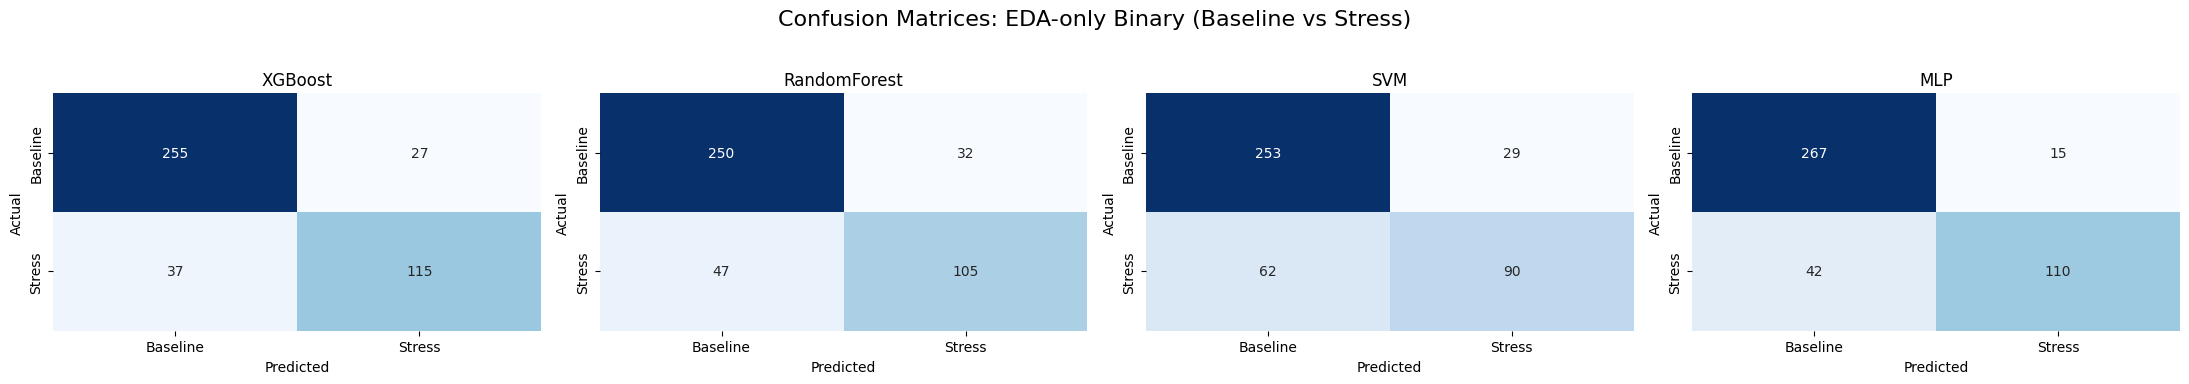


 Task: EDA-only 3-Class (Baseline vs Stress vs Meditation)
 N subjects: 15
 N samples : 518
[XGBoost     ] Acc: 0.6602 | F1-Macro: 0.5851
              precision    recall  f1-score   support

    Baseline     0.6773    0.7518    0.7126       282
      Stress     0.8308    0.7105    0.7660       152
  Meditation     0.2933    0.2619    0.2767        84

    accuracy                         0.6602       518
   macro avg     0.6005    0.5747    0.5851       518
weighted avg     0.6601    0.6602    0.6576       518

[RandomForest] Acc: 0.6660 | F1-Macro: 0.6054
              precision    recall  f1-score   support

    Baseline     0.6865    0.7376    0.7111       282
      Stress     0.7826    0.7105    0.7448       152
  Meditation     0.3766    0.3452    0.3602        84

    accuracy                         0.6660       518
   macro avg     0.6152    0.5978    0.6054       518
weighted avg     0.6644    0.6660    0.6641       518

[SVM         ] Acc: 0.6680 | F1-Macro: 0.4745
       

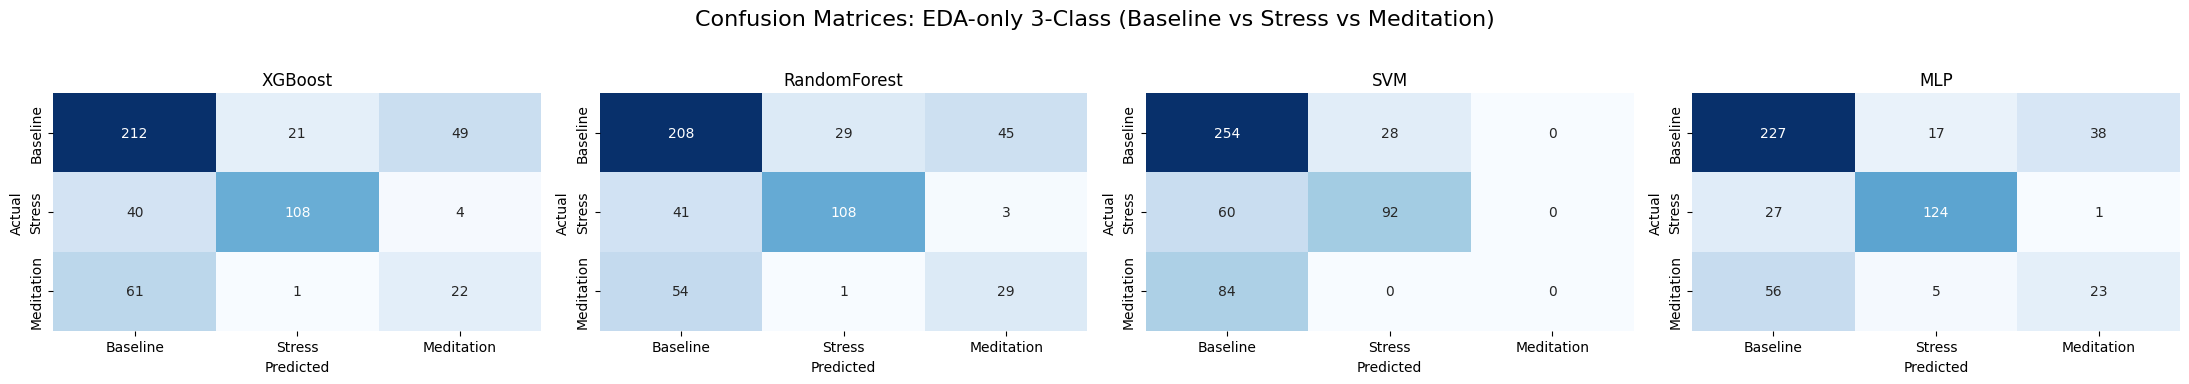


[INFO] Saved LOSO results: /content/drive/MyDrive/Colab Notebooks/BP/EDA_only_csv/EDA_only_LOSO_results.csv

[INFO] Final summary
                                               task        model      acc  f1_macro
               EDA-only Binary (Baseline vs Stress)      XGBoost 0.852535  0.835407
               EDA-only Binary (Baseline vs Stress) RandomForest 0.817972  0.795101
               EDA-only Binary (Baseline vs Stress)          SVM 0.790323  0.755889
               EDA-only Binary (Baseline vs Stress)          MLP 0.868664  0.848889
EDA-only 3-Class (Baseline vs Stress vs Meditation)      XGBoost 0.660232  0.585097
EDA-only 3-Class (Baseline vs Stress vs Meditation) RandomForest 0.666023  0.605396
EDA-only 3-Class (Baseline vs Stress vs Meditation)          SVM 0.667954  0.474510
EDA-only 3-Class (Baseline vs Stress vs Meditation)          MLP 0.722008  0.638058


In [2]:
import os
import glob
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import iqr, skew, kurtosis
from scipy.signal import find_peaks

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =============================================================================
# CONFIG
# =============================================================================
PKL_DIR = r"/content/drive/MyDrive/Colab Notebooks/BP/data/WESAD/pkl_data"
OUTPUT_DIR = r"/content/drive/MyDrive/Colab Notebooks/BP/EDA_only_csv"
os.makedirs(OUTPUT_DIR, exist_ok=True)

FS_LABEL = 700
FS_EDA = 4

WINDOW_SEC = 60
STEP_SEC = 60   # non-overlap

LABEL_BASELINE = 1
LABEL_STRESS = 2
LABEL_MEDITATION  = 4

STATUS_MAP = {
    LABEL_BASELINE: 0,
    LABEL_STRESS: 1,
    LABEL_MEDITATION : 2
}
STATUS_NAME_MAP = {
    LABEL_BASELINE: "baseline",
    LABEL_STRESS: "stress",
    LABEL_MEDITATION : "meditation"
}

LABEL_COL = "label_major"
SUBJECT_COL = "subject"

EDA_FEATURE_COLS = [
    "EDA_mean",
    "EDA_std",
    "EDA_min",
    "EDA_max",
    "EDA_median",
    "EDA_iqr",
    "EDA_skew",
    "EDA_kurtosis",
    "EDA_slope",
    "EDA_range",
    "EDA_diff_mean",
    "EDA_diff_std",
    "EDA_num_peaks",
    "EDA_peak_mean",
    "EDA_peak_max",
]


# =============================================================================
# Basic utils
# =============================================================================
def fill_nan_with_median(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32).reshape(-1).copy()
    if np.isnan(x).any():
        med = np.nanmedian(x)
        if np.isnan(med):
            med = 0.0
        x = np.nan_to_num(x, nan=med, posinf=med, neginf=med)
    return x


def safe_skew(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if len(x) > 2 and np.std(x) > 1e-12:
        v = skew(x)
        return float(v) if np.isfinite(v) else 0.0
    return 0.0


def safe_kurtosis(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if len(x) > 3 and np.std(x) > 1e-12:
        v = kurtosis(x)
        return float(v) if np.isfinite(v) else 0.0
    return 0.0


def map_label_index_to_signal_index(sig_len: int, fs_sig: int, fs_label: int) -> np.ndarray:
    """
    signal sample index -> label index 매핑
    """
    idx = np.round(np.arange(sig_len) * fs_label / fs_sig).astype(int)
    return idx


# =============================================================================
# Find target blocks: first baseline, first stress, last label-4
# (BVP 코드 정책 그대로)
# =============================================================================
def find_target_blocks(labels: np.ndarray):
    labels = np.asarray(labels).reshape(-1)
    if len(labels) == 0:
        return {}

    segments = []
    start = 0
    cur = labels[0]

    for i in range(1, len(labels)):
        if labels[i] != cur:
            segments.append((int(cur), start, i))
            start = i
            cur = labels[i]

    segments.append((int(cur), start, len(labels)))

    baseline_seg = None
    stress_seg = None
    meditation_seg = None

    for lab, s, e in segments:
        if lab == LABEL_BASELINE:
            baseline_seg = (s, e)
            break

    for lab, s, e in segments:
        if lab == LABEL_STRESS:
            stress_seg = (s, e)
            break

    for lab, s, e in reversed(segments):
        if lab == LABEL_MEDITATION :
            meditation_seg = (s, e)
            break

    out = {}
    if baseline_seg is not None:
        out[LABEL_BASELINE] = baseline_seg
    if stress_seg is not None:
        out[LABEL_STRESS] = stress_seg
    if meditation_seg is not None:
        out[LABEL_MEDITATION ] = meditation_seg

    return out


def window_fully_in_block(start_l: int, end_l: int, label_major: int, target_blocks: dict) -> bool:
    if label_major not in target_blocks:
        return False
    blk_s, blk_e = target_blocks[label_major]
    return (start_l >= blk_s) and (end_l <= blk_e)


# =============================================================================
# EDA feature extraction
# =============================================================================
def compute_eda_features(seg_eda: np.ndarray, fs: int = FS_EDA) -> dict:
    x = np.asarray(seg_eda, dtype=np.float32).reshape(-1)
    x = fill_nan_with_median(x)

    feat = {}

    feat["EDA_mean"] = float(np.mean(x))
    feat["EDA_std"] = float(np.std(x))
    feat["EDA_min"] = float(np.min(x))
    feat["EDA_max"] = float(np.max(x))
    feat["EDA_median"] = float(np.median(x))
    feat["EDA_iqr"] = float(iqr(x))
    feat["EDA_skew"] = safe_skew(x)
    feat["EDA_kurtosis"] = safe_kurtosis(x)
    feat["EDA_range"] = float(np.max(x) - np.min(x))

    # slope
    if len(x) > 1:
        t = np.arange(len(x), dtype=np.float32) / float(fs)
        p = np.polyfit(t, x, 1)
        feat["EDA_slope"] = float(p[0])
    else:
        feat["EDA_slope"] = 0.0

    # derivative stats
    dx = np.diff(x)
    if len(dx) > 0:
        feat["EDA_diff_mean"] = float(np.mean(np.abs(dx)))
        feat["EDA_diff_std"] = float(np.std(dx))
    else:
        feat["EDA_diff_mean"] = 0.0
        feat["EDA_diff_std"] = 0.0

    # simple peak stats
    # EDA는 느리므로 distance를 넉넉히 둠
    peak_distance = max(1, int(fs * 1.0))
    peaks, _ = find_peaks(x, distance=peak_distance)

    feat["EDA_num_peaks"] = int(len(peaks))
    if len(peaks) > 0:
        feat["EDA_peak_mean"] = float(np.mean(x[peaks]))
        feat["EDA_peak_max"] = float(np.max(x[peaks]))
    else:
        feat["EDA_peak_mean"] = 0.0
        feat["EDA_peak_max"] = 0.0

    return feat


# =============================================================================
# Build table for one subject
# =============================================================================
def build_subject_eda_windows_table(pkl_path: str, subject_name: str) -> pd.DataFrame:
    with open(pkl_path, "rb") as f:
        s = pickle.load(f, encoding="latin1")

    eda = np.asarray(s["signal"]["wrist"]["EDA"]).reshape(-1).astype(np.float32)
    labels = np.asarray(s["label"]).reshape(-1).astype(np.int64)

    eda = fill_nan_with_median(eda)

    # EDA duration에 맞게 label 자르기
    dur_eda = len(eda) / FS_EDA
    labels = labels[: int(dur_eda * FS_LABEL)]

    target_blocks = find_target_blocks(labels)
    if len(target_blocks) == 0:
        return pd.DataFrame()

    Wl = int(WINDOW_SEC * FS_LABEL)
    Sl = int(STEP_SEC * FS_LABEL)
    We = int(WINDOW_SEC * FS_EDA)

    rows = []
    window_counter = 0

    for start_l in range(0, len(labels) - Wl + 1, Sl):
        end_l = start_l + Wl
        win_lab = labels[start_l:end_l]

        binc = np.bincount(win_lab)
        maj = int(np.argmax(binc))
        maj_ratio = float((win_lab == maj).mean())

        if maj not in [LABEL_BASELINE, LABEL_STRESS, LABEL_MEDITATION]:
            continue
        if maj_ratio < 0.95:
            continue
        if not window_fully_in_block(start_l, end_l, maj, target_blocks):
            continue

        t0 = start_l / FS_LABEL
        t1 = t0 + WINDOW_SEC

        start_e = int(round(t0 * FS_EDA))
        end_e = start_e + We

        if end_e > len(eda):
            continue

        seg_eda = eda[start_e:end_e]
        if len(seg_eda) != We:
            continue

        feat = compute_eda_features(seg_eda, fs=FS_EDA)

        window_counter += 1

        row = {
            "subject": subject_name,
            "window": f"window{window_counter}",
            "window_index": window_counter,
            "status": STATUS_MAP[maj],
            "status_name": STATUS_NAME_MAP[maj],
            "label_major": maj,
            "t_start_sec": float(t0),
            "t_end_sec": float(t1),
            "major_ratio": maj_ratio,
        }

        for k, v in feat.items():
            row[k] = v

        rows.append(row)

    return pd.DataFrame(rows)


# =============================================================================
# Build all subjects
# =============================================================================
def build_all_subjects_eda_windows_table(pkl_dir: str) -> pd.DataFrame:
    pkl_list = sorted(glob.glob(os.path.join(pkl_dir, "S*.pkl")))
    all_dfs = []

    print(f"[INFO] Found {len(pkl_list)} pkl files")

    for pkl_path in pkl_list:
        subject_name = os.path.splitext(os.path.basename(pkl_path))[0]
        print(f"\n[INFO] Processing {subject_name} ...")
        try:
            df_sub = build_subject_eda_windows_table(pkl_path, subject_name)
            print(f"[INFO] {subject_name}: extracted {len(df_sub)} EDA windows")
            if len(df_sub) > 0:
                all_dfs.append(df_sub)
        except Exception as e:
            print(f"[WARN] Failed on {subject_name}: {e}")

    if len(all_dfs) == 0:
        return pd.DataFrame()

    return pd.concat(all_dfs, axis=0, ignore_index=True)


# =============================================================================
# Model definitions
# =============================================================================
def get_models(num_classes: int):
    objective = "binary:logistic" if num_classes == 2 else "multi:softprob"

    return {
        "XGBoost": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            objective=objective,
            random_state=42,
            use_label_encoder=False,
            eval_metric="logloss",
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),
        "SVM": SVC(
            kernel="rbf",
            C=1.0,
            probability=True,
            random_state=42
        ),
        "MLP": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            alpha=1e-4,
            solver="adam",
            random_state=42
        )
    }


# =============================================================================
# LOSO evaluation
# =============================================================================
def run_loso_evaluation(data: pd.DataFrame, feature_cols: list, task_name: str, class_names: list):
    subjects = sorted(data[SUBJECT_COL].unique())
    num_classes = len(class_names)
    models_dict = get_models(num_classes)

    print(f"\n{'='*80}")
    print(f" Task: {task_name}")
    print(f" N subjects: {len(subjects)}")
    print(f" N samples : {len(data)}")
    print(f"{'='*80}")

    fig, axes = plt.subplots(1, 4, figsize=(22, 4))
    fig.suptitle(f"Confusion Matrices: {task_name}", fontsize=16)

    results = []

    for idx, (m_name, model) in enumerate(models_dict.items()):
        all_preds = []
        all_trues = []

        for test_subj in subjects:
            train_df = data[data[SUBJECT_COL] != test_subj].copy()
            test_df = data[data[SUBJECT_COL] == test_subj].copy()

            X_train, y_train = train_df[feature_cols], train_df["target"]
            X_test, y_test = test_df[feature_cols], test_df["target"]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            all_preds.extend(preds)
            all_trues.extend(y_test)

        acc = accuracy_score(all_trues, all_preds)
        f1 = f1_score(all_trues, all_preds, average="macro")

        print(f"[{m_name:12}] Acc: {acc:.4f} | F1-Macro: {f1:.4f}")
        print(classification_report(all_trues, all_preds, target_names=class_names, digits=4))

        results.append({
            "task": task_name,
            "model": m_name,
            "acc": acc,
            "f1_macro": f1
        })

        cm = confusion_matrix(all_trues, all_preds)
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=axes[idx],
            cbar=False,
            xticklabels=class_names,
            yticklabels=class_names
        )
        axes[idx].set_title(m_name)
        axes[idx].set_xlabel("Predicted")
        axes[idx].set_ylabel("Actual")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return pd.DataFrame(results)


# =============================================================================
# Main
# =============================================================================
if __name__ == "__main__":
    # -------------------------------------------------------------------------
    # 1) Extract EDA-only window table
    # -------------------------------------------------------------------------
    df_eda = build_all_subjects_eda_windows_table(PKL_DIR)

    print("\n[INFO] final EDA shape:", df_eda.shape)
    if len(df_eda) == 0:
        print("[WARN] No EDA windows extracted.")
        raise SystemExit

    base_cols = [
        "subject", "window", "window_index",
        "status", "status_name", "label_major",
        "t_start_sec", "t_end_sec", "major_ratio"
    ]
    final_cols = base_cols + EDA_FEATURE_COLS
    df_eda = df_eda[final_cols].copy()

    csv_path = os.path.join(OUTPUT_DIR, "WESAD_EDA_only_windows.csv")
    df_eda.to_csv(csv_path, index=False)
    print(f"[INFO] Saved EDA window CSV: {csv_path}")

    print("\n[INFO] Status counts")
    print(df_eda["status_name"].value_counts())

    print("\n[INFO] Subject x status counts")
    print(
        df_eda.groupby(["subject", "status_name"])
        .size()
        .reset_index(name="n_windows")
        .to_string(index=False)
    )

    # -------------------------------------------------------------------------
    # 2) Binary classification: baseline vs stress
    # -------------------------------------------------------------------------
    df_bin = df_eda[df_eda[LABEL_COL].isin([1, 2])].copy()
    le_bin = LabelEncoder()
    df_bin["target"] = le_bin.fit_transform(df_bin[LABEL_COL])   # 1->0, 2->1

    result_bin = run_loso_evaluation(
        df_bin,
        EDA_FEATURE_COLS,
        "EDA-only Binary (Baseline vs Stress)",
        ["Baseline", "Stress"]
    )

    # -------------------------------------------------------------------------
    # 3) 3-class classification: baseline vs stress vs label4
    # -------------------------------------------------------------------------
    df_tri = df_eda[df_eda[LABEL_COL].isin([1, 2, 4])].copy()
    le_tri = LabelEncoder()
    df_tri["target"] = le_tri.fit_transform(df_tri[LABEL_COL])   # 1->0, 2->1, 4->2

    result_tri = run_loso_evaluation(
        df_tri,
        EDA_FEATURE_COLS,
        "EDA-only 3-Class (Baseline vs Stress vs Meditation)",
        ["Baseline", "Stress", "Meditation"]
    )

    # -------------------------------------------------------------------------
    # 4) Save summary
    # -------------------------------------------------------------------------
    df_results = pd.concat([result_bin, result_tri], axis=0, ignore_index=True)
    results_csv = os.path.join(OUTPUT_DIR, "EDA_only_LOSO_results.csv")
    df_results.to_csv(results_csv, index=False)
    print(f"\n[INFO] Saved LOSO results: {results_csv}")
    print("\n[INFO] Final summary")
    print(df_results.to_string(index=False))

# 1-2) raw EDA-only Personalized

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neural_network import MLPClassifier
import numpy as np
import pandas as pd


def run_personalized_model_mlp(df, features, label_col, subject_col, task="binary"):
    """
    Personalized evaluation (subject-dependent) with class-wise temporal split

    split rule (within each class block):
        first 70% -> train
        last 10%  -> test
        middle 20% -> unused
    """

    subjects = sorted(df[subject_col].unique())
    results = []

    print("\n" + "=" * 75)
    print(f"Personalized evaluation with MLP ({task}, class-wise temporal split)")
    print("=" * 75)
    print(f"{'Subject':<8} | {'Train':<6} | {'Test':<6} | {'Acc':<8} | {'F1-macro':<10}")
    print("-" * 75)

    for subj in subjects:
        subj_df = df[df[subject_col] == subj].copy()

        if task == "binary":
            label_map = {1: 0, 2: 1}
            valid_labels = [1, 2]
        else:
            label_map = {1: 0, 2: 1, 4: 2}
            valid_labels = [1, 2, 4]

        subj_df = subj_df[subj_df[label_col].isin(valid_labels)].copy()

        if len(subj_df) == 0:
            continue

        subj_df = subj_df.sort_values("window_index").reset_index(drop=True)

        train_parts = []
        test_parts = []

        for lab in valid_labels:
            cls_df = subj_df[subj_df[label_col] == lab].copy()
            cls_df = cls_df.sort_values("window_index").reset_index(drop=True)

            n_cls = len(cls_df)
            if n_cls < 10:
                continue

            train_end = int(n_cls * 0.7)
            test_start = int(n_cls * 0.9)

            cls_train = cls_df.iloc[:train_end].copy()
            cls_test = cls_df.iloc[test_start:].copy()

            if len(cls_train) == 0 or len(cls_test) == 0:
                continue

            train_parts.append(cls_train)
            test_parts.append(cls_test)

        if len(train_parts) == 0 or len(test_parts) == 0:
            continue

        train_df = pd.concat(train_parts, axis=0).sort_values("window_index").reset_index(drop=True)
        test_df = pd.concat(test_parts, axis=0).sort_values("window_index").reset_index(drop=True)

        train_df["target"] = train_df[label_col].map(label_map)
        test_df["target"] = test_df[label_col].map(label_map)

        X_train = train_df[features].values
        y_train = train_df["target"].values
        X_test = test_df[features].values
        y_test = test_df["target"].values

        # binary면 최소 2클래스, 3class면 가능하면 3클래스가 train/test에 모두 있는 게 가장 좋음
        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            continue

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            max_iter=500,
            random_state=42
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average="macro", zero_division=0)

        results.append({
            "subject": subj,
            "train_n": len(X_train),
            "test_n": len(X_test),
            "acc": acc,
            "f1": f1
        })

        print(f"{subj:<8} | {len(X_train):<6} | {len(X_test):<6} | {acc:<8.4f} | {f1:<10.4f}")

    print("-" * 75)

    if len(results) == 0:
        print("No valid subjects for this split setting.")
        return pd.DataFrame(columns=["subject", "train_n", "test_n", "acc", "f1"])

    avg_acc = np.mean([r["acc"] for r in results])
    avg_f1 = np.mean([r["f1"] for r in results])

    print(f"{'AVG':<25} | {avg_acc:<8.4f} | {avg_f1:<10.4f}")

    return pd.DataFrame(results)


# Binary personalized
perf_bin_mlp = run_personalized_model_mlp(
    df_eda,
    EDA_FEATURE_COLS,
    LABEL_COL,
    SUBJECT_COL,
    task="binary"
)

# 3-class personalized
perf_tri_mlp = run_personalized_model_mlp(
    df_eda,
    EDA_FEATURE_COLS,
    LABEL_COL,
    SUBJECT_COL,
    task="3class"
)


Personalized evaluation with MLP (binary, class-wise temporal split)
Subject  | Train  | Test   | Acc      | F1-macro  
---------------------------------------------------------------------------
S10      | 20     | 4      | 1.0000   | 1.0000    
S11      | 20     | 4      | 0.7500   | 0.7333    
S13      | 20     | 3      | 1.0000   | 1.0000    
S14      | 20     | 3      | 0.3333   | 0.2500    
S15      | 20     | 4      | 1.0000   | 1.0000    
S16      | 20     | 3      | 1.0000   | 1.0000    
S17      | 20     | 4      | 0.7500   | 0.7333    
S2       | 19     | 3      | 1.0000   | 1.0000    
S3       | 19     | 3      | 0.6667   | 0.4000    
S6       | 20     | 3      | 1.0000   | 1.0000    
S7       | 20     | 3      | 1.0000   | 1.0000    
S8       | 20     | 4      | 1.0000   | 1.0000    
---------------------------------------------------------------------------
AVG                       | 0.8750   | 0.8431    

Personalized evaluation with MLP (3class, class-wise temporal sp

# 2-1) Raw BVP-only binary/3-class ML

[INFO] Found 15 pkl files

[INFO] Processing S10 ...
[INFO] S10: extracted 36 BVP windows

[INFO] Processing S11 ...
[INFO] S11: extracted 35 BVP windows

[INFO] Processing S13 ...
[INFO] S13: extracted 35 BVP windows

[INFO] Processing S14 ...
[INFO] S14: extracted 35 BVP windows

[INFO] Processing S15 ...
[INFO] S15: extracted 35 BVP windows

[INFO] Processing S16 ...
[INFO] S16: extracted 35 BVP windows

[INFO] Processing S17 ...
[INFO] S17: extracted 36 BVP windows

[INFO] Processing S2 ...
[INFO] S2: extracted 33 BVP windows

[INFO] Processing S3 ...
[INFO] S3: extracted 34 BVP windows

[INFO] Processing S4 ...
[INFO] S4: extracted 34 BVP windows

[INFO] Processing S5 ...
[INFO] S5: extracted 33 BVP windows

[INFO] Processing S6 ...
[INFO] S6: extracted 34 BVP windows

[INFO] Processing S7 ...
[INFO] S7: extracted 35 BVP windows

[INFO] Processing S8 ...
[INFO] S8: extracted 36 BVP windows

[INFO] Processing S9 ...
[INFO] S9: extracted 32 BVP windows

[INFO] final BVP shape: (518,

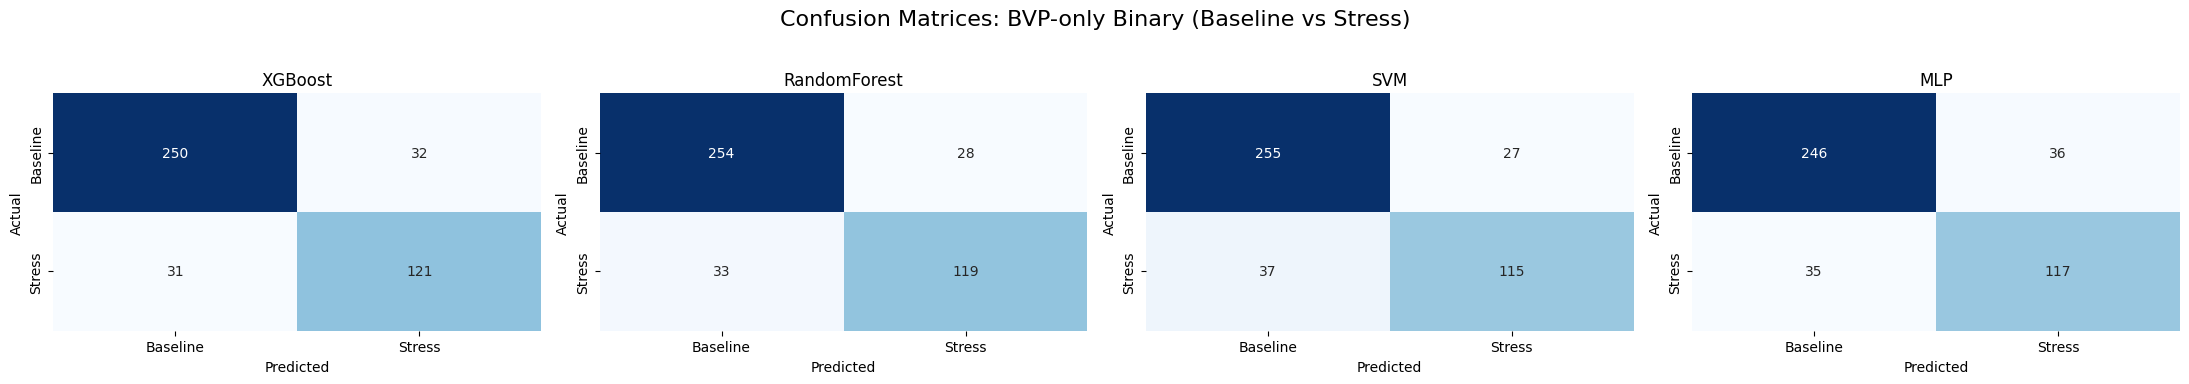


 Task: BVP-only 3-Class (Baseline vs Stress vs Meditation)
 N subjects: 15
 N samples : 518
[XGBoost     ] Acc: 0.7201 | F1-Macro: 0.6546
              precision    recall  f1-score   support

    Baseline     0.7533    0.8014    0.7766       282
      Stress     0.7233    0.7566    0.7395       152
  Meditation     0.5424    0.3810    0.4476        84

    accuracy                         0.7201       518
   macro avg     0.6730    0.6463    0.6546       518
weighted avg     0.7103    0.7201    0.7124       518

[RandomForest] Acc: 0.7355 | F1-Macro: 0.6784
              precision    recall  f1-score   support

    Baseline     0.7651    0.8085    0.7862       282
      Stress     0.7358    0.7697    0.7524       152
  Meditation     0.5902    0.4286    0.4966        84

    accuracy                         0.7355       518
   macro avg     0.6970    0.6689    0.6784       518
weighted avg     0.7281    0.7355    0.7293       518

[SVM         ] Acc: 0.7490 | F1-Macro: 0.6741
       

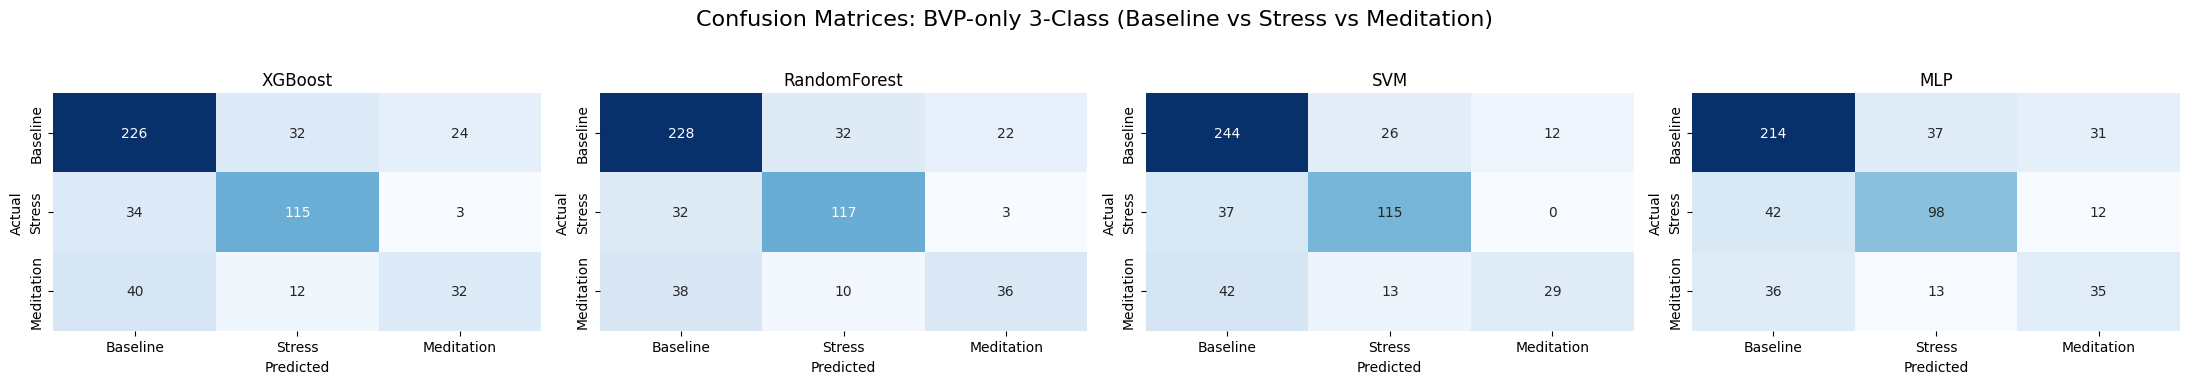


[INFO] Saved LOSO results: /content/drive/MyDrive/Colab Notebooks/BP/BVP_only_csv/BVP_only_LOSO_results.csv

[INFO] Final summary
                                               task        model      acc  f1_macro
               BVP-only Binary (Baseline vs Stress)      XGBoost 0.854839  0.840771
               BVP-only Binary (Baseline vs Stress) RandomForest 0.859447  0.844390
               BVP-only Binary (Baseline vs Stress)          SVM 0.852535  0.835407
               BVP-only Binary (Baseline vs Stress)          MLP 0.836406  0.820551
BVP-only 3-Class (Baseline vs Stress vs Meditation)      XGBoost 0.720077  0.654578
BVP-only 3-Class (Baseline vs Stress vs Meditation) RandomForest 0.735521  0.678390
BVP-only 3-Class (Baseline vs Stress vs Meditation)          SVM 0.749035  0.674082
BVP-only 3-Class (Baseline vs Stress vs Meditation)          MLP 0.669884  0.610359


In [5]:
import os
import glob
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import iqr, skew, kurtosis
from scipy.signal import find_peaks

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =============================================================================
# CONFIG
# =============================================================================
PKL_DIR = r"/content/drive/MyDrive/Colab Notebooks/BP/data/WESAD/pkl_data"
OUTPUT_DIR = r"/content/drive/MyDrive/Colab Notebooks/BP/BVP_only_csv"
os.makedirs(OUTPUT_DIR, exist_ok=True)

FS_LABEL = 700
FS_BVP = 64

WINDOW_SEC = 60
STEP_SEC = 60   # non-overlap

LABEL_BASELINE = 1
LABEL_STRESS = 2
LABEL_MEDITATION = 4

STATUS_MAP = {
    LABEL_BASELINE: 0,
    LABEL_STRESS: 1,
    LABEL_MEDITATION: 2
}
STATUS_NAME_MAP = {
    LABEL_BASELINE: "baseline",
    LABEL_STRESS: "stress",
    LABEL_MEDITATION: "meditation"
}

LABEL_COL = "label_major"
SUBJECT_COL = "subject"

BVP_FEATURE_COLS = [
    "BVP_mean",
    "BVP_std",
    "BVP_min",
    "BVP_max",
    "BVP_median",
    "BVP_iqr",
    "BVP_skew",
    "BVP_kurtosis",
    "BVP_slope",
    "BVP_range",
    "BVP_diff_mean",
    "BVP_diff_std",
    "BVP_num_peaks",
    "BVP_peak_mean",
    "BVP_peak_max",
]


# =============================================================================
# Basic utils
# =============================================================================
def fill_nan_with_median(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32).reshape(-1).copy()
    if np.isnan(x).any():
        med = np.nanmedian(x)
        if np.isnan(med):
            med = 0.0
        x = np.nan_to_num(x, nan=med, posinf=med, neginf=med)
    return x


def safe_skew(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if len(x) > 2 and np.std(x) > 1e-12:
        v = skew(x)
        return float(v) if np.isfinite(v) else 0.0
    return 0.0


def safe_kurtosis(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if len(x) > 3 and np.std(x) > 1e-12:
        v = kurtosis(x)
        return float(v) if np.isfinite(v) else 0.0
    return 0.0


# =============================================================================
# Find target blocks: first baseline, first stress, last meditation
# =============================================================================
def find_target_blocks(labels: np.ndarray):
    labels = np.asarray(labels).reshape(-1)
    if len(labels) == 0:
        return {}

    segments = []
    start = 0
    cur = labels[0]

    for i in range(1, len(labels)):
        if labels[i] != cur:
            segments.append((int(cur), start, i))
            start = i
            cur = labels[i]

    segments.append((int(cur), start, len(labels)))

    baseline_seg = None
    stress_seg = None
    meditation_seg = None

    for lab, s, e in segments:
        if lab == LABEL_BASELINE:
            baseline_seg = (s, e)
            break

    for lab, s, e in segments:
        if lab == LABEL_STRESS:
            stress_seg = (s, e)
            break

    for lab, s, e in reversed(segments):
        if lab == LABEL_MEDITATION:
            meditation_seg = (s, e)
            break

    out = {}
    if baseline_seg is not None:
        out[LABEL_BASELINE] = baseline_seg
    if stress_seg is not None:
        out[LABEL_STRESS] = stress_seg
    if meditation_seg is not None:
        out[LABEL_MEDITATION] = meditation_seg

    return out


def window_fully_in_block(start_l: int, end_l: int, label_major: int, target_blocks: dict) -> bool:
    if label_major not in target_blocks:
        return False
    blk_s, blk_e = target_blocks[label_major]
    return (start_l >= blk_s) and (end_l <= blk_e)


# =============================================================================
# BVP feature extraction
# =============================================================================
def compute_bvp_features(seg_bvp: np.ndarray, fs: int = FS_BVP) -> dict:
    x = np.asarray(seg_bvp, dtype=np.float32).reshape(-1)
    x = fill_nan_with_median(x)

    feat = {}

    feat["BVP_mean"] = float(np.mean(x))
    feat["BVP_std"] = float(np.std(x))
    feat["BVP_min"] = float(np.min(x))
    feat["BVP_max"] = float(np.max(x))
    feat["BVP_median"] = float(np.median(x))
    feat["BVP_iqr"] = float(iqr(x))
    feat["BVP_skew"] = safe_skew(x)
    feat["BVP_kurtosis"] = safe_kurtosis(x)
    feat["BVP_range"] = float(np.max(x) - np.min(x))

    if len(x) > 1:
        t = np.arange(len(x), dtype=np.float32) / float(fs)
        p = np.polyfit(t, x, 1)
        feat["BVP_slope"] = float(p[0])
    else:
        feat["BVP_slope"] = 0.0

    dx = np.diff(x)
    if len(dx) > 0:
        feat["BVP_diff_mean"] = float(np.mean(np.abs(dx)))
        feat["BVP_diff_std"] = float(np.std(dx))
    else:
        feat["BVP_diff_mean"] = 0.0
        feat["BVP_diff_std"] = 0.0

    # BVP는 더 빠르므로 peak distance를 짧게
    peak_distance = max(1, int(fs * 0.3))
    peaks, _ = find_peaks(x, distance=peak_distance)

    feat["BVP_num_peaks"] = int(len(peaks))
    if len(peaks) > 0:
        feat["BVP_peak_mean"] = float(np.mean(x[peaks]))
        feat["BVP_peak_max"] = float(np.max(x[peaks]))
    else:
        feat["BVP_peak_mean"] = 0.0
        feat["BVP_peak_max"] = 0.0

    return feat


# =============================================================================
# Build table for one subject
# =============================================================================
def build_subject_bvp_windows_table(pkl_path: str, subject_name: str) -> pd.DataFrame:
    with open(pkl_path, "rb") as f:
        s = pickle.load(f, encoding="latin1")

    bvp = np.asarray(s["signal"]["wrist"]["BVP"]).reshape(-1).astype(np.float32)
    labels = np.asarray(s["label"]).reshape(-1).astype(np.int64)

    bvp = fill_nan_with_median(bvp)

    dur_bvp = len(bvp) / FS_BVP
    labels = labels[: int(dur_bvp * FS_LABEL)]

    target_blocks = find_target_blocks(labels)
    if len(target_blocks) == 0:
        return pd.DataFrame()

    Wl = int(WINDOW_SEC * FS_LABEL)
    Sl = int(STEP_SEC * FS_LABEL)
    Wb = int(WINDOW_SEC * FS_BVP)

    rows = []
    window_counter = 0

    for start_l in range(0, len(labels) - Wl + 1, Sl):
        end_l = start_l + Wl
        win_lab = labels[start_l:end_l]

        binc = np.bincount(win_lab)
        maj = int(np.argmax(binc))
        maj_ratio = float((win_lab == maj).mean())

        if maj not in [LABEL_BASELINE, LABEL_STRESS, LABEL_MEDITATION]:
            continue
        if maj_ratio < 0.95:
            continue
        if not window_fully_in_block(start_l, end_l, maj, target_blocks):
            continue

        t0 = start_l / FS_LABEL
        t1 = t0 + WINDOW_SEC

        start_b = int(round(t0 * FS_BVP))
        end_b = start_b + Wb

        if end_b > len(bvp):
            continue

        seg_bvp = bvp[start_b:end_b]
        if len(seg_bvp) != Wb:
            continue

        feat = compute_bvp_features(seg_bvp, fs=FS_BVP)

        window_counter += 1

        row = {
            "subject": subject_name,
            "window": f"window{window_counter}",
            "window_index": window_counter,
            "status": STATUS_MAP[maj],
            "status_name": STATUS_NAME_MAP[maj],
            "label_major": maj,
            "t_start_sec": float(t0),
            "t_end_sec": float(t1),
            "major_ratio": maj_ratio,
        }

        for k, v in feat.items():
            row[k] = v

        rows.append(row)

    return pd.DataFrame(rows)


# =============================================================================
# Build all subjects
# =============================================================================
def build_all_subjects_bvp_windows_table(pkl_dir: str) -> pd.DataFrame:
    pkl_list = sorted(glob.glob(os.path.join(pkl_dir, "S*.pkl")))
    all_dfs = []

    print(f"[INFO] Found {len(pkl_list)} pkl files")

    for pkl_path in pkl_list:
        subject_name = os.path.splitext(os.path.basename(pkl_path))[0]
        print(f"\n[INFO] Processing {subject_name} ...")
        try:
            df_sub = build_subject_bvp_windows_table(pkl_path, subject_name)
            print(f"[INFO] {subject_name}: extracted {len(df_sub)} BVP windows")
            if len(df_sub) > 0:
                all_dfs.append(df_sub)
        except Exception as e:
            print(f"[WARN] Failed on {subject_name}: {e}")

    if len(all_dfs) == 0:
        return pd.DataFrame()

    return pd.concat(all_dfs, axis=0, ignore_index=True)


# =============================================================================
# Model definitions
# =============================================================================
def get_models(num_classes: int):
    objective = "binary:logistic" if num_classes == 2 else "multi:softprob"

    return {
        "XGBoost": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            objective=objective,
            random_state=42,
            use_label_encoder=False,
            eval_metric="logloss",
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),
        "SVM": SVC(
            kernel="rbf",
            C=1.0,
            probability=True,
            random_state=42
        ),
        "MLP": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            alpha=1e-4,
            solver="adam",
            random_state=42
        )
    }


# =============================================================================
# LOSO evaluation
# =============================================================================
def run_loso_evaluation(data: pd.DataFrame, feature_cols: list, task_name: str, class_names: list):
    subjects = sorted(data[SUBJECT_COL].unique())
    num_classes = len(class_names)
    models_dict = get_models(num_classes)

    print(f"\n{'='*80}")
    print(f" Task: {task_name}")
    print(f" N subjects: {len(subjects)}")
    print(f" N samples : {len(data)}")
    print(f"{'='*80}")

    fig, axes = plt.subplots(1, 4, figsize=(22, 4))
    fig.suptitle(f"Confusion Matrices: {task_name}", fontsize=16)

    results = []

    for idx, (m_name, model) in enumerate(models_dict.items()):
        all_preds = []
        all_trues = []

        for test_subj in subjects:
            train_df = data[data[SUBJECT_COL] != test_subj].copy()
            test_df = data[data[SUBJECT_COL] == test_subj].copy()

            X_train, y_train = train_df[feature_cols], train_df["target"]
            X_test, y_test = test_df[feature_cols], test_df["target"]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            all_preds.extend(preds)
            all_trues.extend(y_test)

        acc = accuracy_score(all_trues, all_preds)
        f1 = f1_score(all_trues, all_preds, average="macro")

        print(f"[{m_name:12}] Acc: {acc:.4f} | F1-Macro: {f1:.4f}")
        print(classification_report(all_trues, all_preds, target_names=class_names, digits=4))

        results.append({
            "task": task_name,
            "model": m_name,
            "acc": acc,
            "f1_macro": f1
        })

        cm = confusion_matrix(all_trues, all_preds)
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=axes[idx],
            cbar=False,
            xticklabels=class_names,
            yticklabels=class_names
        )
        axes[idx].set_title(m_name)
        axes[idx].set_xlabel("Predicted")
        axes[idx].set_ylabel("Actual")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return pd.DataFrame(results)


# =============================================================================
# Main
# =============================================================================
if __name__ == "__main__":
    # -------------------------------------------------------------------------
    # 1) Extract BVP-only window table
    # -------------------------------------------------------------------------
    df_bvp = build_all_subjects_bvp_windows_table(PKL_DIR)

    print("\n[INFO] final BVP shape:", df_bvp.shape)
    if len(df_bvp) == 0:
        print("[WARN] No BVP windows extracted.")
        raise SystemExit

    base_cols = [
        "subject", "window", "window_index",
        "status", "status_name", "label_major",
        "t_start_sec", "t_end_sec", "major_ratio"
    ]
    final_cols = base_cols + BVP_FEATURE_COLS
    df_bvp = df_bvp[final_cols].copy()

    csv_path = os.path.join(OUTPUT_DIR, "WESAD_BVP_only_windows.csv")
    df_bvp.to_csv(csv_path, index=False)
    print(f"[INFO] Saved BVP window CSV: {csv_path}")

    print("\n[INFO] Status counts")
    print(df_bvp["status_name"].value_counts())

    print("\n[INFO] Subject x status counts")
    print(
        df_bvp.groupby(["subject", "status_name"])
        .size()
        .reset_index(name="n_windows")
        .to_string(index=False)
    )

    # -------------------------------------------------------------------------
    # 2) Binary classification: baseline vs stress
    # -------------------------------------------------------------------------
    df_bin = df_bvp[df_bvp[LABEL_COL].isin([1, 2])].copy()
    le_bin = LabelEncoder()
    df_bin["target"] = le_bin.fit_transform(df_bin[LABEL_COL])   # 1->0, 2->1

    result_bin = run_loso_evaluation(
        df_bin,
        BVP_FEATURE_COLS,
        "BVP-only Binary (Baseline vs Stress)",
        ["Baseline", "Stress"]
    )

    # -------------------------------------------------------------------------
    # 3) 3-class classification: baseline vs stress vs meditation
    # -------------------------------------------------------------------------
    df_tri = df_bvp[df_bvp[LABEL_COL].isin([1, 2, 4])].copy()
    le_tri = LabelEncoder()
    df_tri["target"] = le_tri.fit_transform(df_tri[LABEL_COL])   # 1->0, 2->1, 4->2

    result_tri = run_loso_evaluation(
        df_tri,
        BVP_FEATURE_COLS,
        "BVP-only 3-Class (Baseline vs Stress vs Meditation)",
        ["Baseline", "Stress", "Meditation"]
    )

    # -------------------------------------------------------------------------
    # 4) Save summary
    # -------------------------------------------------------------------------
    df_results = pd.concat([result_bin, result_tri], axis=0, ignore_index=True)
    results_csv = os.path.join(OUTPUT_DIR, "BVP_only_LOSO_results.csv")
    df_results.to_csv(results_csv, index=False)
    print(f"\n[INFO] Saved LOSO results: {results_csv}")
    print("\n[INFO] Final summary")
    print(df_results.to_string(index=False))

# 2-2) raw PPG-only Personalized

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd


def run_personalized_rf(df, features, label_col, subject_col, task="binary"):
    """
    Personalized evaluation (subject-dependent) with RandomForest

    split rule (within each class block):
        first 70% -> train
        last 10%  -> test
        middle 20% -> unused
    """

    subjects = sorted(df[subject_col].unique())
    results = []

    print("\n" + "=" * 75)
    print(f"Personalized evaluation with RF ({task}, class-wise temporal split)")
    print("=" * 75)
    print(f"{'Subject':<8} | {'Train':<6} | {'Test':<6} | {'Acc':<8} | {'F1-macro':<10}")
    print("-" * 75)

    for subj in subjects:
        subj_df = df[df[subject_col] == subj].copy()

        if task == "binary":
            label_map = {1: 0, 2: 1}
            valid_labels = [1, 2]
        else:
            label_map = {1: 0, 2: 1, 4: 2}
            valid_labels = [1, 2, 4]

        subj_df = subj_df[subj_df[label_col].isin(valid_labels)].copy()

        if len(subj_df) == 0:
            continue

        subj_df = subj_df.sort_values("window_index").reset_index(drop=True)

        train_parts = []
        test_parts = []

        for lab in valid_labels:
            cls_df = subj_df[subj_df[label_col] == lab].copy()
            cls_df = cls_df.sort_values("window_index").reset_index(drop=True)

            n_cls = len(cls_df)
            if n_cls < 10:
                continue

            train_end = int(n_cls * 0.7)
            test_start = int(n_cls * 0.9)

            cls_train = cls_df.iloc[:train_end].copy()
            cls_test = cls_df.iloc[test_start:].copy()

            if len(cls_train) == 0 or len(cls_test) == 0:
                continue

            train_parts.append(cls_train)
            test_parts.append(cls_test)

        if len(train_parts) == 0 or len(test_parts) == 0:
            continue

        train_df = pd.concat(train_parts, axis=0).sort_values("window_index").reset_index(drop=True)
        test_df = pd.concat(test_parts, axis=0).sort_values("window_index").reset_index(drop=True)

        train_df["target"] = train_df[label_col].map(label_map)
        test_df["target"] = test_df[label_col].map(label_map)

        X_train = train_df[features].values
        y_train = train_df["target"].values
        X_test = test_df[features].values
        y_test = test_df["target"].values

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            continue

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average="macro", zero_division=0)

        results.append({
            "subject": subj,
            "train_n": len(X_train),
            "test_n": len(X_test),
            "acc": acc,
            "f1": f1
        })

        print(f"{subj:<8} | {len(X_train):<6} | {len(X_test):<6} | {acc:<8.4f} | {f1:<10.4f}")

    print("-" * 75)

    if len(results) == 0:
        print("No valid subjects for this split setting.")
        return pd.DataFrame(columns=["subject", "train_n", "test_n", "acc", "f1"])

    avg_acc = np.mean([r["acc"] for r in results])
    avg_f1 = np.mean([r["f1"] for r in results])

    print(f"{'AVG':<25} | {avg_acc:<8.4f} | {avg_f1:<10.4f}")

    return pd.DataFrame(results)


perf_bin_bvp_rf = run_personalized_rf(
    df_bvp,
    BVP_FEATURE_COLS,
    LABEL_COL,
    SUBJECT_COL,
    task="binary"
)

perf_tri_bvp_rf = run_personalized_rf(
    df_bvp,
    BVP_FEATURE_COLS,
    LABEL_COL,
    SUBJECT_COL,
    task="3class"
)


Personalized evaluation with RF (binary, class-wise temporal split)
Subject  | Train  | Test   | Acc      | F1-macro  
---------------------------------------------------------------------------
S10      | 20     | 4      | 0.5000   | 0.3333    
S11      | 20     | 4      | 1.0000   | 1.0000    
S13      | 20     | 3      | 0.6667   | 0.4000    
S14      | 20     | 3      | 1.0000   | 1.0000    
S15      | 20     | 4      | 0.5000   | 0.3333    
S16      | 20     | 3      | 1.0000   | 1.0000    
S17      | 20     | 4      | 1.0000   | 1.0000    
S2       | 19     | 3      | 0.3333   | 0.2500    
S3       | 19     | 3      | 0.6667   | 0.6667    
S6       | 20     | 3      | 1.0000   | 1.0000    
S7       | 20     | 3      | 0.6667   | 0.4000    
S8       | 20     | 4      | 0.5000   | 0.3333    
---------------------------------------------------------------------------
AVG                       | 0.7361   | 0.6431    

Personalized evaluation with RF (3class, class-wise temporal spli

# 3-1) BVP-TPV with QC

[INFO] Loaded CSV shape: (429, 52)
[INFO] Columns:
['subject', 'window', 'window_index', 'status', 'status_name', 'label_major', 't_start_sec', 't_end_sec', 'major_ratio', 'bvp_missing_ratio', 'acc_missing_ratio', 'missing_flag', 'flatline_flag', 'clipping_ratio', 'clipping_flag', 'n_peaks', 'peak_sparse_flag', 'ibi_pass_ratio', 'valid_beat_ratio', 'ibi_plausibility', 'ibi_mean_sec', 'median_template_corr', 'notch_foot_peak_detectability', 'acc_diff_mean', 'acc_diff_exceed_ratio', 'acc_diff_flag', 'psd_corr_x', 'psd_corr_y', 'psd_corr_z', 'psd_corr_mag', 'psd_corr_max', 'psd_corr_flag', 'motion_score_raw', 'motion_score', 'SQI_stress_basic', 'SQI_stress_morph', 'hard_reject', 'motion_threshold_subject_p80', 'qc_relaxed_pass', 'TPV22', 'TPV9', 'TPV4', 'TPV2', 'TPV0', 'TPV28', 'TPV8', 'TPV19', 'TPV14', 'TPV26', 'TPV11', 'acc_diff_threshold_subject', 'acc_diff_flag_subject']

[INFO] Label counts
label_major
1    255
2     92
4     82
Name: count, dtype: int64

[INFO] Subject x label count

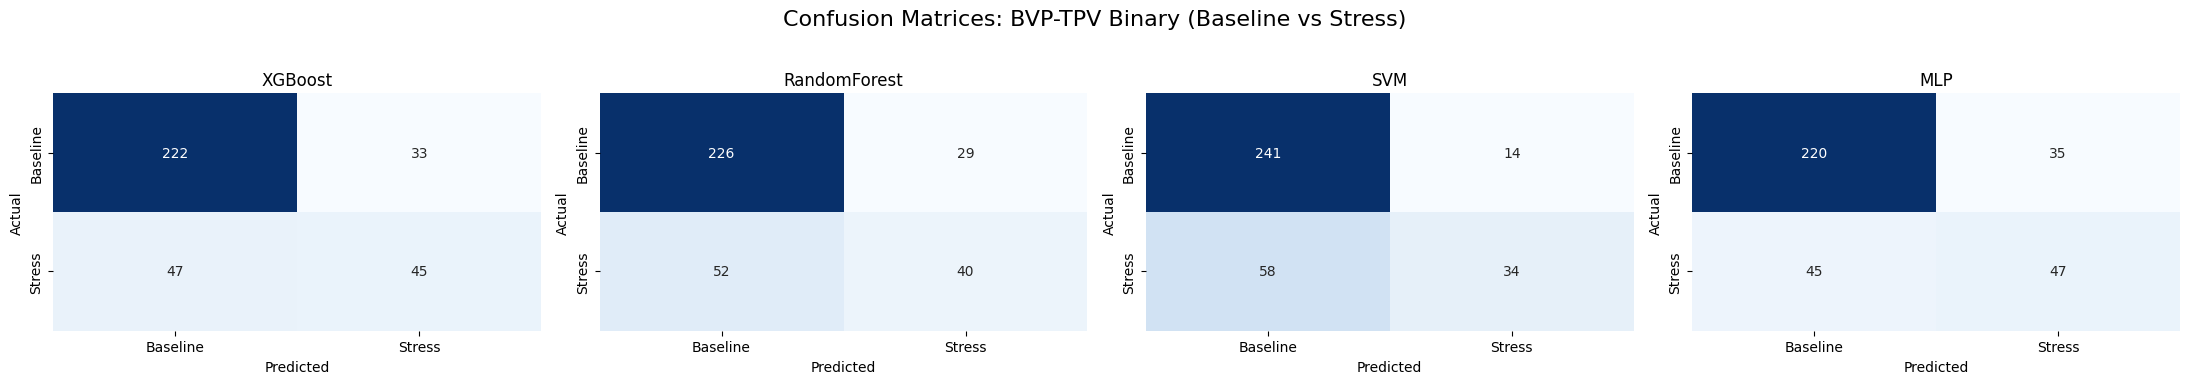


 Task: BVP-TPV 3-Class (Baseline vs Stress vs Meditation)
 N subjects: 15
 N samples : 429
[XGBoost     ] Acc: 0.6643 | F1-Macro: 0.5857
              precision    recall  f1-score   support

    Baseline     0.7148    0.8157    0.7619       255
      Stress     0.4937    0.4239    0.4561        92
  Meditation     0.6441    0.4634    0.5390        82

    accuracy                         0.6643       429
   macro avg     0.6175    0.5677    0.5857       429
weighted avg     0.6538    0.6643    0.6537       429

[RandomForest] Acc: 0.6597 | F1-Macro: 0.5706
              precision    recall  f1-score   support

    Baseline     0.7020    0.8314    0.7612       255
      Stress     0.4933    0.4022    0.4431        92
  Meditation     0.6538    0.4146    0.5075        82

    accuracy                         0.6597       429
   macro avg     0.6164    0.5494    0.5706       429
weighted avg     0.6480    0.6597    0.6445       429

[SVM         ] Acc: 0.6853 | F1-Macro: 0.5667
        

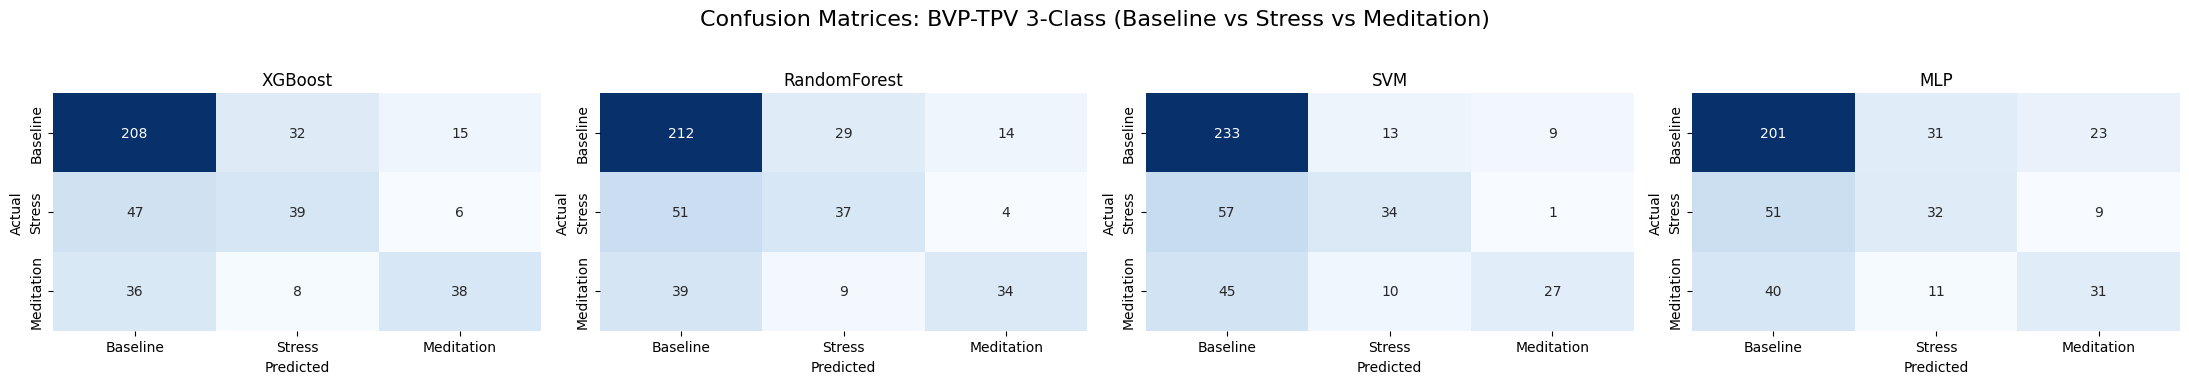


[INFO] Saved LOSO results: /mnt/data/tpv_eval_results/BVP_TPV_LOSO_results.csv

[INFO] Final summary
                                              task        model      acc  f1_macro
               BVP-TPV Binary (Baseline vs Stress)      XGBoost 0.769452  0.688370
               BVP-TPV Binary (Baseline vs Stress) RandomForest 0.766571  0.672462
               BVP-TPV Binary (Baseline vs Stress)          SVM 0.792507  0.677875
               BVP-TPV Binary (Baseline vs Stress)          MLP 0.769452  0.693192
BVP-TPV 3-Class (Baseline vs Stress vs Meditation)      XGBoost 0.664336  0.585684
BVP-TPV 3-Class (Baseline vs Stress vs Meditation) RandomForest 0.659674  0.570599
BVP-TPV 3-Class (Baseline vs Stress vs Meditation)          SVM 0.685315  0.566663
BVP-TPV 3-Class (Baseline vs Stress vs Meditation)          MLP 0.615385  0.516015


In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =============================================================================
# CONFIG
# =============================================================================
CSV_PATH = r"/content/drive/MyDrive/Colab Notebooks/BP/TPV-csv/after_motion-artifact_removed.csv"
OUTPUT_DIR = r"/mnt/data/tpv_eval_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

LABEL_COL = "label_major"
SUBJECT_COL = "subject"

TPV_COLS = [
    "TPV22", "TPV9", "TPV4", "TPV2", "TPV0",
    "TPV28", "TPV8", "TPV19", "TPV14", "TPV26", "TPV11"
]


# =============================================================================
# Model definitions
# =============================================================================
def get_models(num_classes: int):
    objective = "binary:logistic" if num_classes == 2 else "multi:softprob"

    return {
        "XGBoost": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            objective=objective,
            random_state=42,
            use_label_encoder=False,
            eval_metric="logloss",
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),
        "SVM": SVC(
            kernel="rbf",
            C=1.0,
            probability=True,
            random_state=42
        ),
        "MLP": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            alpha=1e-4,
            solver="adam",
            random_state=42
        )
    }


# =============================================================================
# LOSO evaluation
# =============================================================================
def run_loso_evaluation(data: pd.DataFrame, feature_cols: list, task_name: str, class_names: list):
    subjects = sorted(data[SUBJECT_COL].unique())
    num_classes = len(class_names)
    models_dict = get_models(num_classes)

    print(f"\n{'='*80}")
    print(f" Task: {task_name}")
    print(f" N subjects: {len(subjects)}")
    print(f" N samples : {len(data)}")
    print(f"{'='*80}")

    fig, axes = plt.subplots(1, 4, figsize=(22, 4))
    fig.suptitle(f"Confusion Matrices: {task_name}", fontsize=16)

    results = []

    for idx, (m_name, model) in enumerate(models_dict.items()):
        all_preds = []
        all_trues = []

        for test_subj in subjects:
            train_df = data[data[SUBJECT_COL] != test_subj].copy()
            test_df = data[data[SUBJECT_COL] == test_subj].copy()

            X_train, y_train = train_df[feature_cols], train_df["target"]
            X_test, y_test = test_df[feature_cols], test_df["target"]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            all_preds.extend(preds)
            all_trues.extend(y_test)

        acc = accuracy_score(all_trues, all_preds)
        f1 = f1_score(all_trues, all_preds, average="macro")

        print(f"[{m_name:12}] Acc: {acc:.4f} | F1-Macro: {f1:.4f}")
        print(classification_report(all_trues, all_preds, target_names=class_names, digits=4))

        results.append({
            "task": task_name,
            "model": m_name,
            "acc": acc,
            "f1_macro": f1
        })

        cm = confusion_matrix(all_trues, all_preds)
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=axes[idx],
            cbar=False,
            xticklabels=class_names,
            yticklabels=class_names
        )
        axes[idx].set_title(m_name)
        axes[idx].set_xlabel("Predicted")
        axes[idx].set_ylabel("Actual")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return pd.DataFrame(results)


# =============================================================================
# Main
# =============================================================================
if __name__ == "__main__":
    df = pd.read_csv(CSV_PATH)

    print("[INFO] Loaded CSV shape:", df.shape)
    print("[INFO] Columns:")
    print(df.columns.tolist())

    # TPV 컬럼 존재 확인
    missing_cols = [c for c in TPV_COLS if c not in df.columns]
    if len(missing_cols) > 0:
        raise ValueError(f"Missing TPV columns: {missing_cols}")

    # 필요 컬럼만 확인
    keep_cols = [SUBJECT_COL, LABEL_COL] + TPV_COLS
    df = df[keep_cols].copy()

    print("\n[INFO] Label counts")
    print(df[LABEL_COL].value_counts().sort_index())

    print("\n[INFO] Subject x label counts")
    print(
        df.groupby([SUBJECT_COL, LABEL_COL])
          .size()
          .reset_index(name="n_windows")
          .to_string(index=False)
    )

    # -------------------------------------------------------------------------
    # 1) Binary classification: baseline vs stress
    # -------------------------------------------------------------------------
    df_bin = df[df[LABEL_COL].isin([1, 2])].copy()
    le_bin = LabelEncoder()
    df_bin["target"] = le_bin.fit_transform(df_bin[LABEL_COL])   # 1->0, 2->1

    result_bin = run_loso_evaluation(
        df_bin,
        TPV_COLS,
        "BVP-TPV Binary (Baseline vs Stress)",
        ["Baseline", "Stress"]
    )

    # -------------------------------------------------------------------------
    # 2) 3-class classification: baseline vs stress vs meditation
    # -------------------------------------------------------------------------
    df_tri = df[df[LABEL_COL].isin([1, 2, 4])].copy()
    le_tri = LabelEncoder()
    df_tri["target"] = le_tri.fit_transform(df_tri[LABEL_COL])   # 1->0, 2->1, 4->2

    result_tri = run_loso_evaluation(
        df_tri,
        TPV_COLS,
        "BVP-TPV 3-Class (Baseline vs Stress vs Meditation)",
        ["Baseline", "Stress", "Meditation"]
    )

    # -------------------------------------------------------------------------
    # 3) Save results
    # -------------------------------------------------------------------------
    df_results = pd.concat([result_bin, result_tri], axis=0, ignore_index=True)
    results_csv = os.path.join(OUTPUT_DIR, "BVP_TPV_LOSO_results.csv")
    df_results.to_csv(results_csv, index=False)

    print(f"\n[INFO] Saved LOSO results: {results_csv}")
    print("\n[INFO] Final summary")
    print(df_results.to_string(index=False))

# 3-2) BVP-TPV w/o QC

[INFO] Loaded CSV shape: (518, 50)
[INFO] Columns:
['subject', 'window', 'window_index', 'status', 'status_name', 'label_major', 't_start_sec', 't_end_sec', 'major_ratio', 'bvp_missing_ratio', 'acc_missing_ratio', 'missing_flag', 'flatline_flag', 'clipping_ratio', 'clipping_flag', 'n_peaks', 'peak_sparse_flag', 'ibi_pass_ratio', 'valid_beat_ratio', 'ibi_plausibility', 'ibi_mean_sec', 'median_template_corr', 'notch_foot_peak_detectability', 'acc_diff_mean', 'acc_diff_exceed_ratio', 'acc_diff_flag', 'psd_corr_x', 'psd_corr_y', 'psd_corr_z', 'psd_corr_mag', 'psd_corr_max', 'psd_corr_flag', 'motion_score_raw', 'motion_score', 'SQI_stress_basic', 'SQI_stress_morph', 'hard_reject', 'motion_threshold_subject_p80', 'qc_relaxed_pass', 'TPV22', 'TPV9', 'TPV4', 'TPV2', 'TPV0', 'TPV28', 'TPV8', 'TPV19', 'TPV14', 'TPV26', 'TPV11']

[INFO] Label counts
label_major
1    282
2    152
4     84
Name: count, dtype: int64

[INFO] Subject x label counts
subject  label_major  n_windows
    S10            1 

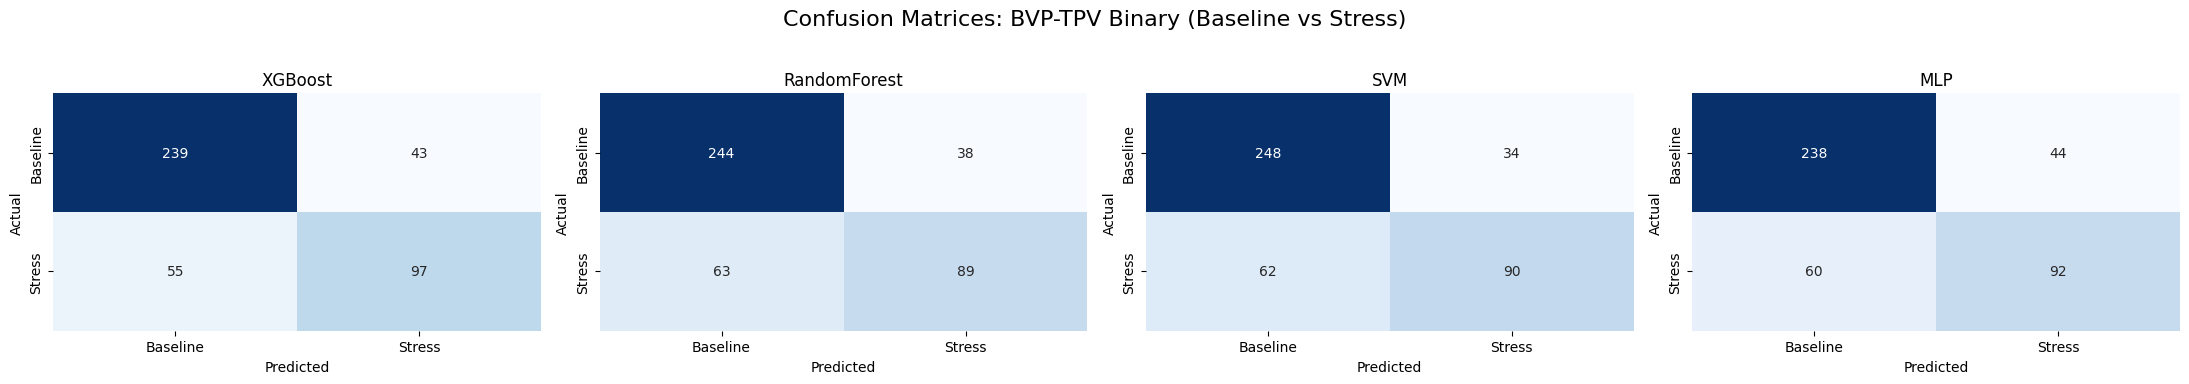


 Task: BVP-TPV 3-Class (Baseline vs Stress vs Meditation)
 N subjects: 15
 N samples : 518
[XGBoost     ] Acc: 0.6737 | F1-Macro: 0.6259
              precision    recall  f1-score   support

    Baseline     0.7029    0.7801    0.7395       282
      Stress     0.6216    0.6053    0.6133       152
  Meditation     0.6491    0.4405    0.5248        84

    accuracy                         0.6737       518
   macro avg     0.6579    0.6086    0.6259       518
weighted avg     0.6703    0.6737    0.6677       518

[RandomForest] Acc: 0.6834 | F1-Macro: 0.6287
              precision    recall  f1-score   support

    Baseline     0.7125    0.7908    0.7496       282
      Stress     0.6486    0.6316    0.6400       152
  Meditation     0.6140    0.4167    0.4965        84

    accuracy                         0.6834       518
   macro avg     0.6584    0.6130    0.6287       518
weighted avg     0.6778    0.6834    0.6764       518

[SVM         ] Acc: 0.6853 | F1-Macro: 0.6067
        

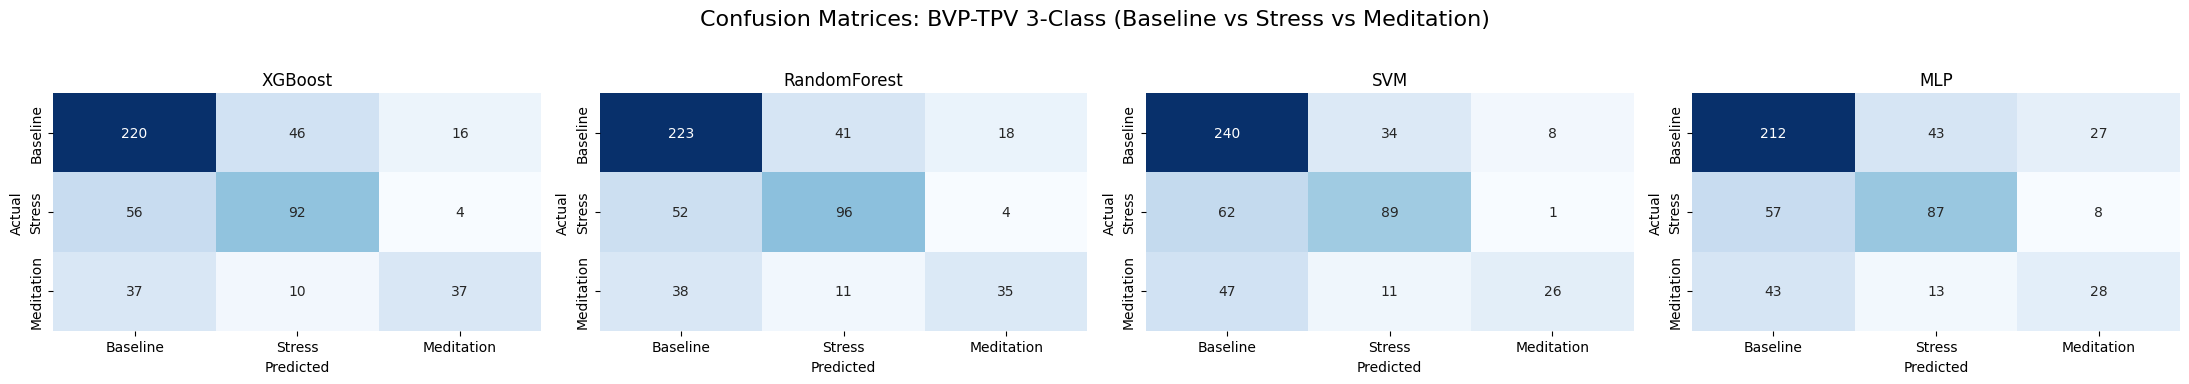


[INFO] Saved LOSO results: /mnt/data/tpv_eval_results/BVP_TPV_LOSO_results.csv

[INFO] Final summary
                                              task        model      acc  f1_macro
               BVP-TPV Binary (Baseline vs Stress)      XGBoost 0.774194  0.747122
               BVP-TPV Binary (Baseline vs Stress) RandomForest 0.767281  0.733258
               BVP-TPV Binary (Baseline vs Stress)          SVM 0.778802  0.745006
               BVP-TPV Binary (Baseline vs Stress)          MLP 0.760369  0.729789
BVP-TPV 3-Class (Baseline vs Stress vs Meditation)      XGBoost 0.673745  0.625884
BVP-TPV 3-Class (Baseline vs Stress vs Meditation) RandomForest 0.683398  0.628678
BVP-TPV 3-Class (Baseline vs Stress vs Meditation)          SVM 0.685328  0.606683
BVP-TPV 3-Class (Baseline vs Stress vs Meditation)          MLP 0.631274  0.561529


In [7]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =============================================================================
# CONFIG
# =============================================================================
CSV_PATH = r"/content/drive/MyDrive/Colab Notebooks/BP/TPV-csv/noQC.csv"
OUTPUT_DIR = r"/mnt/data/tpv_eval_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

LABEL_COL = "label_major"
SUBJECT_COL = "subject"

TPV_COLS = [
    "TPV22", "TPV9", "TPV4", "TPV2", "TPV0",
    "TPV28", "TPV8", "TPV19", "TPV14", "TPV26", "TPV11"
]


# =============================================================================
# Model definitions
# =============================================================================
def get_models(num_classes: int):
    objective = "binary:logistic" if num_classes == 2 else "multi:softprob"

    return {
        "XGBoost": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            objective=objective,
            random_state=42,
            use_label_encoder=False,
            eval_metric="logloss",
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),
        "SVM": SVC(
            kernel="rbf",
            C=1.0,
            probability=True,
            random_state=42
        ),
        "MLP": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            alpha=1e-4,
            solver="adam",
            random_state=42
        )
    }


# =============================================================================
# LOSO evaluation
# =============================================================================
def run_loso_evaluation(data: pd.DataFrame, feature_cols: list, task_name: str, class_names: list):
    subjects = sorted(data[SUBJECT_COL].unique())
    num_classes = len(class_names)
    models_dict = get_models(num_classes)

    print(f"\n{'='*80}")
    print(f" Task: {task_name}")
    print(f" N subjects: {len(subjects)}")
    print(f" N samples : {len(data)}")
    print(f"{'='*80}")

    fig, axes = plt.subplots(1, 4, figsize=(22, 4))
    fig.suptitle(f"Confusion Matrices: {task_name}", fontsize=16)

    results = []

    for idx, (m_name, model) in enumerate(models_dict.items()):
        all_preds = []
        all_trues = []

        for test_subj in subjects:
            train_df = data[data[SUBJECT_COL] != test_subj].copy()
            test_df = data[data[SUBJECT_COL] == test_subj].copy()

            X_train, y_train = train_df[feature_cols], train_df["target"]
            X_test, y_test = test_df[feature_cols], test_df["target"]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            all_preds.extend(preds)
            all_trues.extend(y_test)

        acc = accuracy_score(all_trues, all_preds)
        f1 = f1_score(all_trues, all_preds, average="macro")

        print(f"[{m_name:12}] Acc: {acc:.4f} | F1-Macro: {f1:.4f}")
        print(classification_report(all_trues, all_preds, target_names=class_names, digits=4))

        results.append({
            "task": task_name,
            "model": m_name,
            "acc": acc,
            "f1_macro": f1
        })

        cm = confusion_matrix(all_trues, all_preds)
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=axes[idx],
            cbar=False,
            xticklabels=class_names,
            yticklabels=class_names
        )
        axes[idx].set_title(m_name)
        axes[idx].set_xlabel("Predicted")
        axes[idx].set_ylabel("Actual")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return pd.DataFrame(results)


# =============================================================================
# Main
# =============================================================================
if __name__ == "__main__":
    df = pd.read_csv(CSV_PATH)

    print("[INFO] Loaded CSV shape:", df.shape)
    print("[INFO] Columns:")
    print(df.columns.tolist())

    # TPV 컬럼 존재 확인
    missing_cols = [c for c in TPV_COLS if c not in df.columns]
    if len(missing_cols) > 0:
        raise ValueError(f"Missing TPV columns: {missing_cols}")

    # 필요 컬럼만 확인
    keep_cols = [SUBJECT_COL, LABEL_COL] + TPV_COLS
    df = df[keep_cols].copy()

    print("\n[INFO] Label counts")
    print(df[LABEL_COL].value_counts().sort_index())

    print("\n[INFO] Subject x label counts")
    print(
        df.groupby([SUBJECT_COL, LABEL_COL])
          .size()
          .reset_index(name="n_windows")
          .to_string(index=False)
    )

    # -------------------------------------------------------------------------
    # 1) Binary classification: baseline vs stress
    # -------------------------------------------------------------------------
    df_bin = df[df[LABEL_COL].isin([1, 2])].copy()
    le_bin = LabelEncoder()
    df_bin["target"] = le_bin.fit_transform(df_bin[LABEL_COL])   # 1->0, 2->1

    result_bin = run_loso_evaluation(
        df_bin,
        TPV_COLS,
        "BVP-TPV Binary (Baseline vs Stress)",
        ["Baseline", "Stress"]
    )

    # -------------------------------------------------------------------------
    # 2) 3-class classification: baseline vs stress vs meditation
    # -------------------------------------------------------------------------
    df_tri = df[df[LABEL_COL].isin([1, 2, 4])].copy()
    le_tri = LabelEncoder()
    df_tri["target"] = le_tri.fit_transform(df_tri[LABEL_COL])   # 1->0, 2->1, 4->2

    result_tri = run_loso_evaluation(
        df_tri,
        TPV_COLS,
        "BVP-TPV 3-Class (Baseline vs Stress vs Meditation)",
        ["Baseline", "Stress", "Meditation"]
    )

    # -------------------------------------------------------------------------
    # 3) Save results
    # -------------------------------------------------------------------------
    df_results = pd.concat([result_bin, result_tri], axis=0, ignore_index=True)
    results_csv = os.path.join(OUTPUT_DIR, "BVP_TPV_LOSO_results.csv")
    df_results.to_csv(results_csv, index=False)

    print(f"\n[INFO] Saved LOSO results: {results_csv}")
    print("\n[INFO] Final summary")
    print(df_results.to_string(index=False))

In [10]:
import os
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

# =============================================================================
# CONFIG
# =============================================================================
CSV_PATH = r"/content/drive/MyDrive/Colab Notebooks/BP/TPV-csv/noQC.csv"
OUTPUT_DIR = r"/mnt/data/tpv_eval_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

LABEL_COL = "label_major"
SUBJECT_COL = "subject"

TPV_COLS = [
    "TPV22", "TPV9", "TPV4", "TPV2", "TPV0",
    "TPV28", "TPV8", "TPV19", "TPV14", "TPV26", "TPV11"
]


# =============================================================================
# Personalized SVM evaluation (80:20 split)
# =============================================================================
def run_personalized_svm(df, features, label_col, subject_col, task="binary"):
    """
    Personalized evaluation (subject-dependent) with SVM

    split rule:
        train:test = 80:20
        stratified random split within each subject
    """

    subjects = sorted(df[subject_col].unique())
    results = []

    print("\n" + "=" * 80)
    print(f"Personalized evaluation with SVM ({task}, 80:20 split)")
    print("=" * 80)
    print(f"{'Subject':<8} | {'Train':<6} | {'Test':<6} | {'Acc':<8} | {'F1-macro':<10}")
    print("-" * 80)

    for subj in subjects:
        subj_df = df[df[subject_col] == subj].copy()

        if task == "binary":
            subj_df = subj_df[subj_df[label_col].isin([1, 2])].copy()
            subj_df["target"] = subj_df[label_col].map({1: 0, 2: 1})
        else:
            subj_df = subj_df[subj_df[label_col].isin([1, 2, 4])].copy()
            subj_df["target"] = subj_df[label_col].map({1: 0, 2: 1, 4: 2})

        if len(subj_df) < 15:
            continue

        X = subj_df[features].values
        y = subj_df["target"].values

        if len(np.unique(y)) < 2:
            continue

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y
        )

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = SVC(
            kernel="rbf",
            C=1.0,
            probability=True,
            random_state=42
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average="macro", zero_division=0)

        results.append({
            "task": task,
            "subject": subj,
            "train_n": len(X_train),
            "test_n": len(X_test),
            "acc": acc,
            "f1_macro": f1
        })

        print(f"{subj:<8} | {len(X_train):<6} | {len(X_test):<6} | {acc:<8.4f} | {f1:<10.4f}")

    print("-" * 80)

    if len(results) == 0:
        print("No valid subjects for this split setting.")
        return pd.DataFrame(columns=["task", "subject", "train_n", "test_n", "acc", "f1_macro"])

    avg_acc = np.mean([r["acc"] for r in results])
    avg_f1 = np.mean([r["f1_macro"] for r in results])

    print(f"{'AVG':<27} | {avg_acc:<8.4f} | {avg_f1:<10.4f}")

    return pd.DataFrame(results)


# =============================================================================
# Main
# =============================================================================
if __name__ == "__main__":
    df = pd.read_csv(CSV_PATH)

    print("[INFO] Loaded CSV shape:", df.shape)
    print("[INFO] Columns:")
    print(df.columns.tolist())

    missing_cols = [c for c in TPV_COLS if c not in df.columns]
    if len(missing_cols) > 0:
        raise ValueError(f"Missing TPV columns: {missing_cols}")

    keep_cols = [SUBJECT_COL, LABEL_COL] + TPV_COLS
    df = df[keep_cols].copy()

    print("\n[INFO] Label counts")
    print(df[LABEL_COL].value_counts().sort_index())

    print("\n[INFO] Subject x label counts")
    print(
        df.groupby([SUBJECT_COL, LABEL_COL])
          .size()
          .reset_index(name="n_windows")
          .to_string(index=False)
    )

    # -------------------------------------------------------------------------
    # 1) Binary personalized SVM: baseline vs stress
    # -------------------------------------------------------------------------
    perf_bin_tpv_svm = run_personalized_svm(
        df,
        TPV_COLS,
        LABEL_COL,
        SUBJECT_COL,
        task="binary"
    )

    # -------------------------------------------------------------------------
    # 2) 3-class personalized SVM: baseline vs stress vs meditation
    # -------------------------------------------------------------------------
    perf_tri_tpv_svm = run_personalized_svm(
        df,
        TPV_COLS,
        LABEL_COL,
        SUBJECT_COL,
        task="3class"
    )

    # -------------------------------------------------------------------------
    # 3) Save results
    # -------------------------------------------------------------------------
    df_results = pd.concat([perf_bin_tpv_svm, perf_tri_tpv_svm], axis=0, ignore_index=True)
    results_csv = os.path.join(OUTPUT_DIR, "BVP_TPV_personalized_SVM_80_20_results.csv")
    df_results.to_csv(results_csv, index=False)

    print(f"\n[INFO] Saved personalized SVM results: {results_csv}")
    print("\n[INFO] Final summary")
    print(df_results.to_string(index=False))

[INFO] Loaded CSV shape: (518, 50)
[INFO] Columns:
['subject', 'window', 'window_index', 'status', 'status_name', 'label_major', 't_start_sec', 't_end_sec', 'major_ratio', 'bvp_missing_ratio', 'acc_missing_ratio', 'missing_flag', 'flatline_flag', 'clipping_ratio', 'clipping_flag', 'n_peaks', 'peak_sparse_flag', 'ibi_pass_ratio', 'valid_beat_ratio', 'ibi_plausibility', 'ibi_mean_sec', 'median_template_corr', 'notch_foot_peak_detectability', 'acc_diff_mean', 'acc_diff_exceed_ratio', 'acc_diff_flag', 'psd_corr_x', 'psd_corr_y', 'psd_corr_z', 'psd_corr_mag', 'psd_corr_max', 'psd_corr_flag', 'motion_score_raw', 'motion_score', 'SQI_stress_basic', 'SQI_stress_morph', 'hard_reject', 'motion_threshold_subject_p80', 'qc_relaxed_pass', 'TPV22', 'TPV9', 'TPV4', 'TPV2', 'TPV0', 'TPV28', 'TPV8', 'TPV19', 'TPV14', 'TPV26', 'TPV11']

[INFO] Label counts
label_major
1    282
2    152
4     84
Name: count, dtype: int64

[INFO] Subject x label counts
subject  label_major  n_windows
    S10            1 

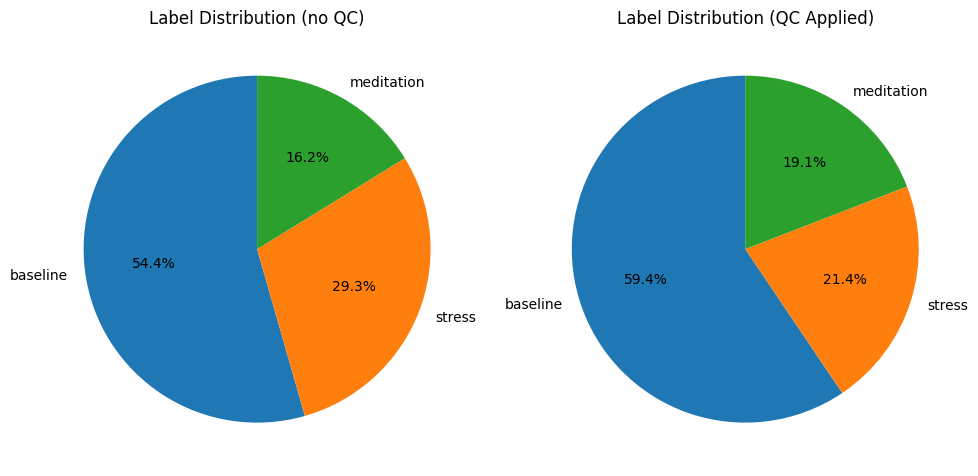

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# FILE PATH
# =========================================================
NO_QC_PATH = "/content/drive/MyDrive/Colab Notebooks/BP/TPV-csv/noQC.csv"
QC_PATH    = "/content/drive/MyDrive/Colab Notebooks/BP/TPV-csv/after_motion-artifact_removed.csv"

# =========================================================
# LOAD
# =========================================================
df_noqc = pd.read_csv(NO_QC_PATH)
df_qc   = pd.read_csv(QC_PATH)

# =========================================================
# LABEL COLUMN (필요하면 수정)
# =========================================================
LABEL_COL = "status"   # 또는 "label"

# label 이름 매핑 (선택)
label_name_map = {
    0: "baseline",
    1: "stress",
    2: "meditation"
}

# =========================================================
# DISTRIBUTION
# =========================================================
dist_noqc = df_noqc[LABEL_COL].value_counts().sort_index()
dist_qc   = df_qc[LABEL_COL].value_counts().sort_index()

labels = [label_name_map.get(i, str(i)) for i in dist_noqc.index]

# =========================================================
# PIE PLOT
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].pie(
    dist_noqc.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
axes[0].set_title("Label Distribution (no QC)")

axes[1].pie(
    dist_qc.values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Label Distribution (QC Applied)")

plt.tight_layout()
plt.show()

# 4-1) BVP-TPV + EDA w/o QC

[INFO] TPV CSV shape: (518, 50)
[INFO] EDA CSV shape: (518, 24)
[INFO] Merged shape: (518, 35)

[INFO] Label counts
label_major
1    282
2    152
4     84
Name: count, dtype: int64

[INFO] Subject x label counts
subject  label_major  n_windows
    S10            1         19
    S10            2         11
    S10            4          6
    S11            1         19
    S11            2         11
    S11            4          5
    S13            1         19
    S13            2         10
    S13            4          6
    S14            1         19
    S14            2         10
    S14            4          6
    S15            1         19
    S15            2         11
    S15            4          5
    S16            1         19
    S16            2         10
    S16            4          6
    S17            1         19
    S17            2         11
    S17            4          6
     S2            1         18
     S2            2         10
     S2            4

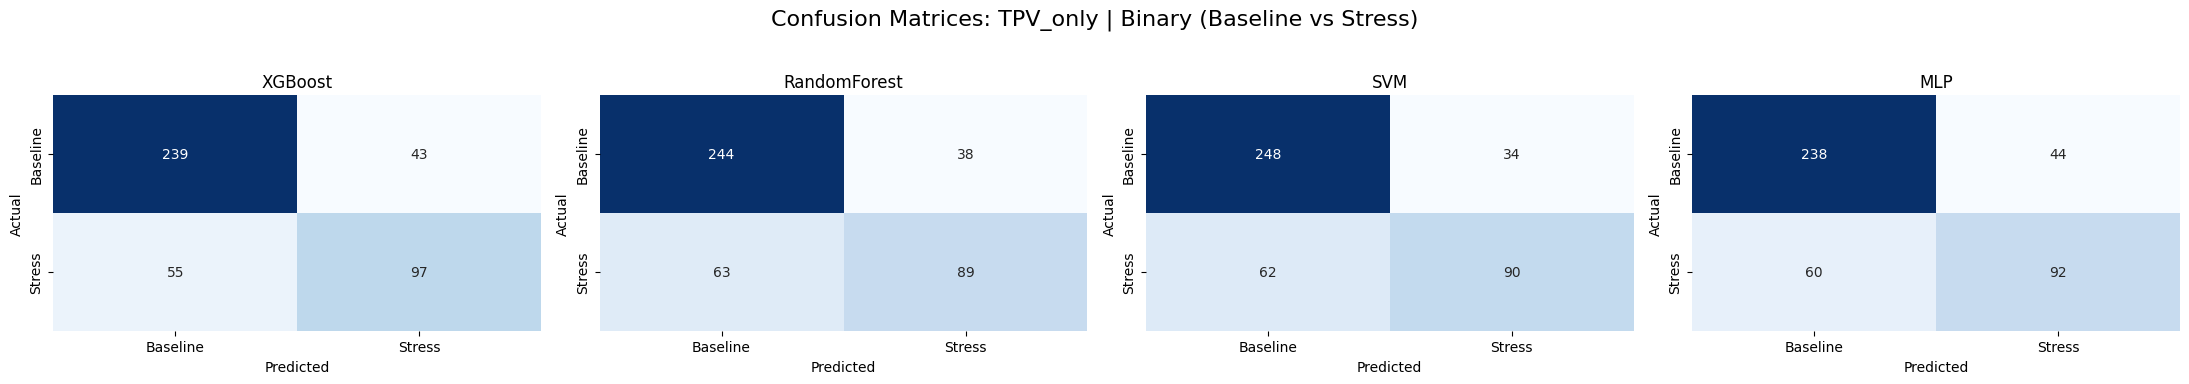


 Task: TPV_only | 3-Class (Baseline vs Stress vs Meditation)
 N subjects: 15
 N samples : 518
 N features: 11
[XGBoost     ] Acc: 0.6737 | F1-Macro: 0.6259
              precision    recall  f1-score   support

    Baseline     0.7029    0.7801    0.7395       282
      Stress     0.6216    0.6053    0.6133       152
  Meditation     0.6491    0.4405    0.5248        84

    accuracy                         0.6737       518
   macro avg     0.6579    0.6086    0.6259       518
weighted avg     0.6703    0.6737    0.6677       518

[RandomForest] Acc: 0.6834 | F1-Macro: 0.6287
              precision    recall  f1-score   support

    Baseline     0.7125    0.7908    0.7496       282
      Stress     0.6486    0.6316    0.6400       152
  Meditation     0.6140    0.4167    0.4965        84

    accuracy                         0.6834       518
   macro avg     0.6584    0.6130    0.6287       518
weighted avg     0.6778    0.6834    0.6764       518

[SVM         ] Acc: 0.6853 | F1-Mac

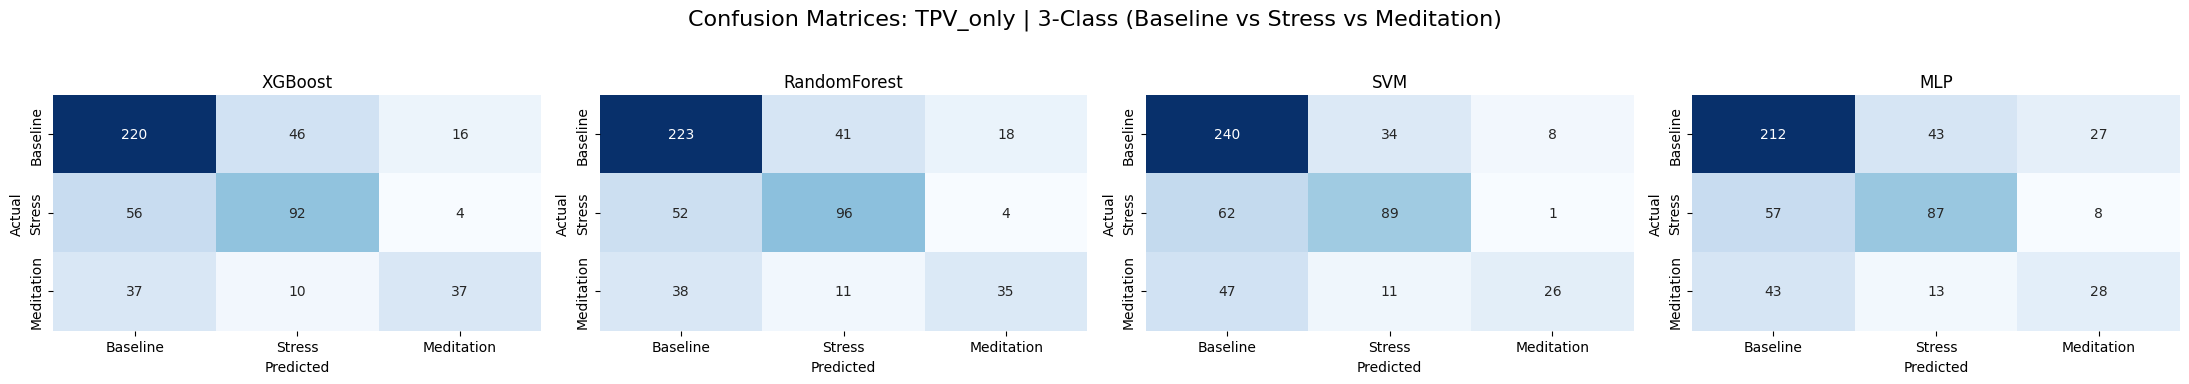


 Task: EDA_only | Binary (Baseline vs Stress)
 N subjects: 15
 N samples : 434
 N features: 15
[XGBoost     ] Acc: 0.8525 | F1-Macro: 0.8354
              precision    recall  f1-score   support

    Baseline     0.8733    0.9043    0.8885       282
      Stress     0.8099    0.7566    0.7823       152

    accuracy                         0.8525       434
   macro avg     0.8416    0.8304    0.8354       434
weighted avg     0.8511    0.8525    0.8513       434

[RandomForest] Acc: 0.8180 | F1-Macro: 0.7951
              precision    recall  f1-score   support

    Baseline     0.8418    0.8865    0.8636       282
      Stress     0.7664    0.6908    0.7266       152

    accuracy                         0.8180       434
   macro avg     0.8041    0.7887    0.7951       434
weighted avg     0.8154    0.8180    0.8156       434

[SVM         ] Acc: 0.7903 | F1-Macro: 0.7559
              precision    recall  f1-score   support

    Baseline     0.8032    0.8972    0.8476       282
   

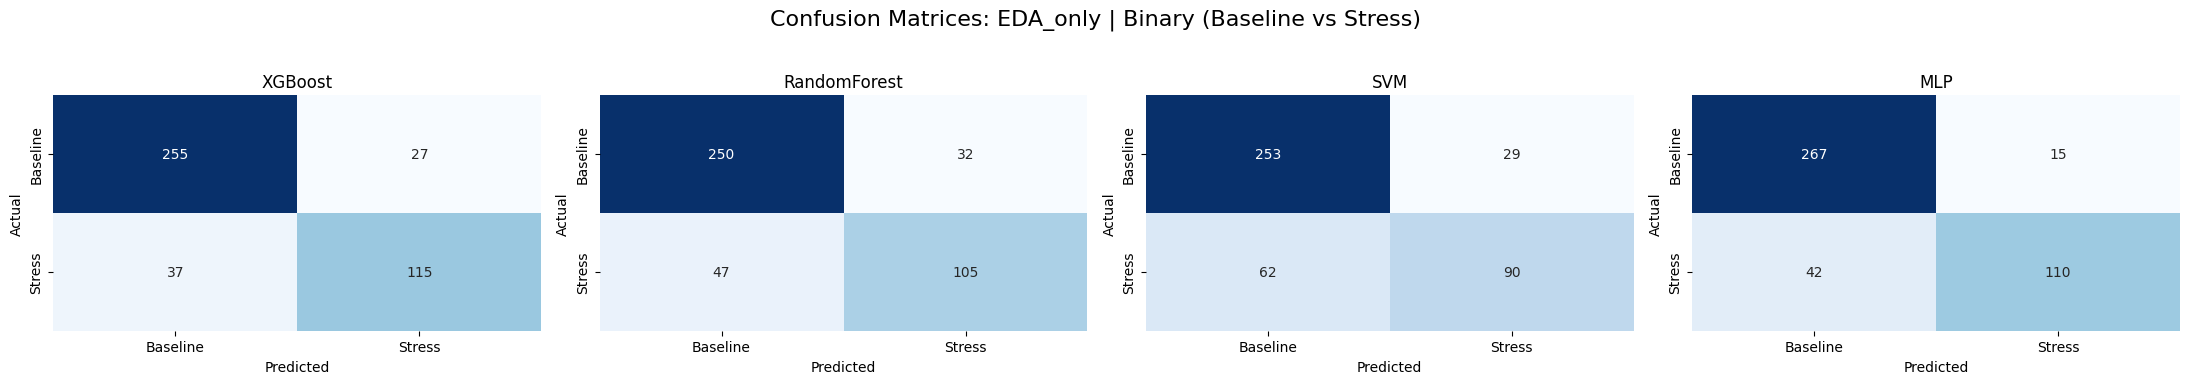


 Task: EDA_only | 3-Class (Baseline vs Stress vs Meditation)
 N subjects: 15
 N samples : 518
 N features: 15
[XGBoost     ] Acc: 0.6602 | F1-Macro: 0.5851
              precision    recall  f1-score   support

    Baseline     0.6773    0.7518    0.7126       282
      Stress     0.8308    0.7105    0.7660       152
  Meditation     0.2933    0.2619    0.2767        84

    accuracy                         0.6602       518
   macro avg     0.6005    0.5747    0.5851       518
weighted avg     0.6601    0.6602    0.6576       518

[RandomForest] Acc: 0.6660 | F1-Macro: 0.6054
              precision    recall  f1-score   support

    Baseline     0.6865    0.7376    0.7111       282
      Stress     0.7826    0.7105    0.7448       152
  Meditation     0.3766    0.3452    0.3602        84

    accuracy                         0.6660       518
   macro avg     0.6152    0.5978    0.6054       518
weighted avg     0.6644    0.6660    0.6641       518

[SVM         ] Acc: 0.6680 | F1-Mac

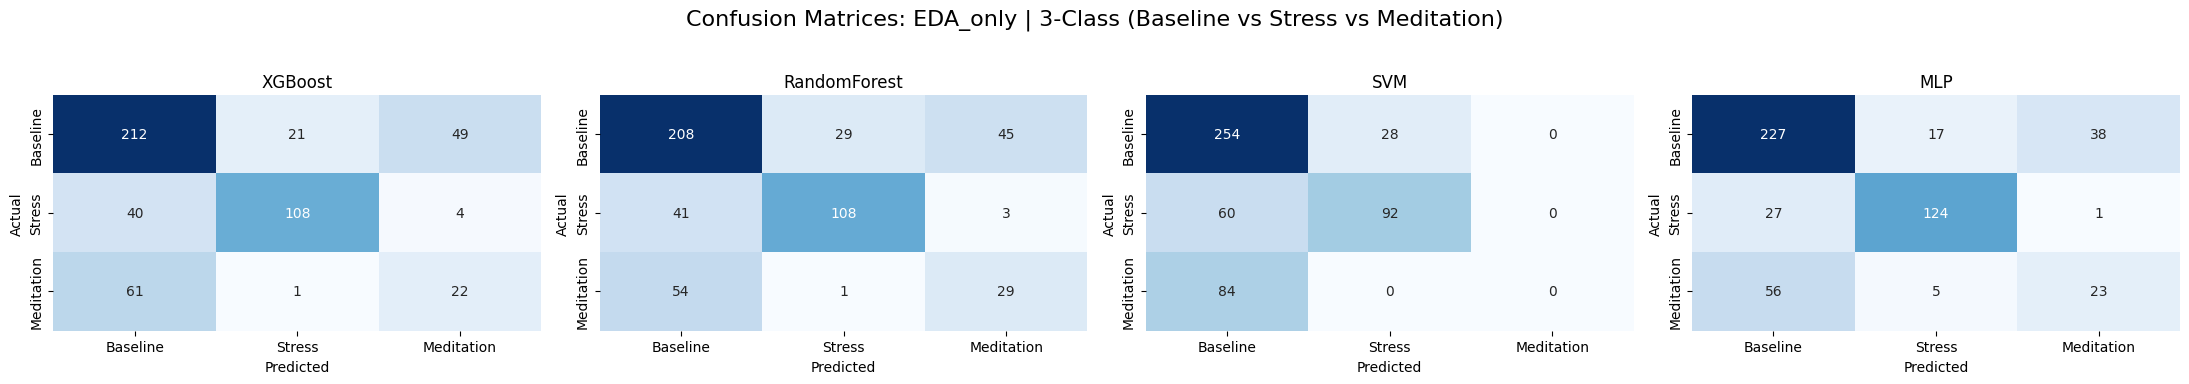


 Task: TPV_plus_EDA | Binary (Baseline vs Stress)
 N subjects: 15
 N samples : 434
 N features: 26
[XGBoost     ] Acc: 0.8618 | F1-Macro: 0.8462
              precision    recall  f1-score   support

    Baseline     0.8828    0.9078    0.8951       282
      Stress     0.8194    0.7763    0.7973       152

    accuracy                         0.8618       434
   macro avg     0.8511    0.8421    0.8462       434
weighted avg     0.8606    0.8618    0.8608       434

[RandomForest] Acc: 0.8479 | F1-Macro: 0.8297
              precision    recall  f1-score   support

    Baseline     0.8673    0.9043    0.8854       282
      Stress     0.8071    0.7434    0.7740       152

    accuracy                         0.8479       434
   macro avg     0.8372    0.8238    0.8297       434
weighted avg     0.8463    0.8479    0.8464       434

[SVM         ] Acc: 0.8111 | F1-Macro: 0.7846
              precision    recall  f1-score   support

    Baseline     0.8289    0.8936    0.8601       282

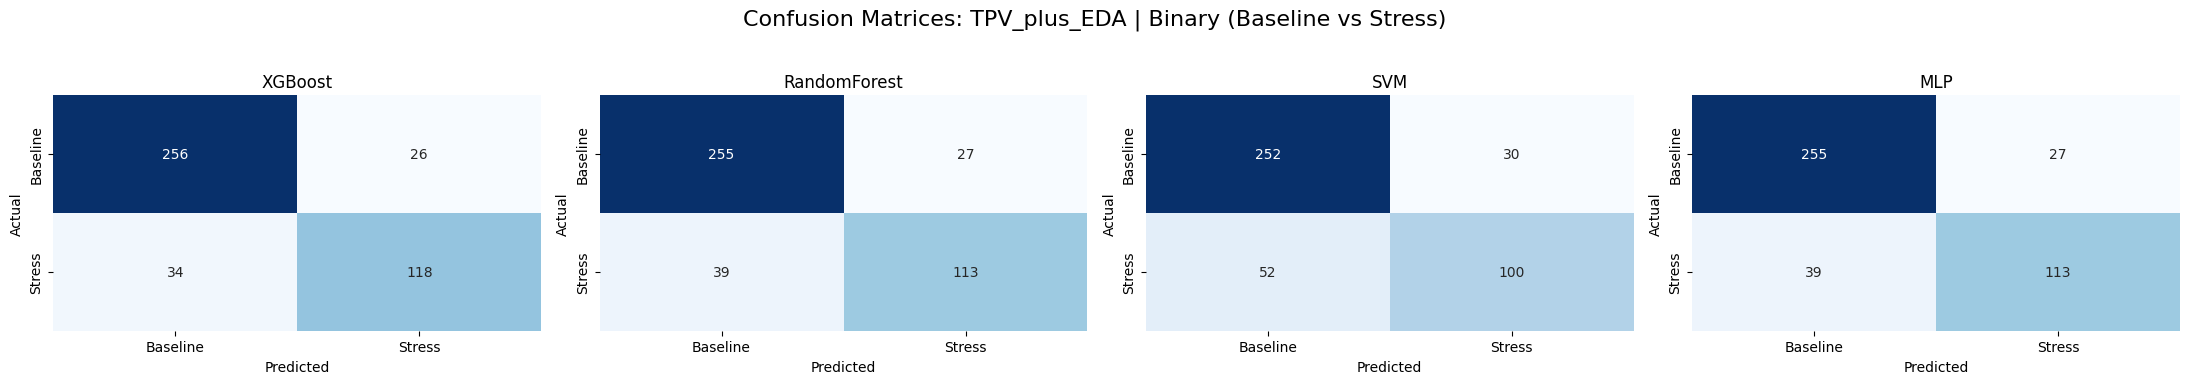


 Task: TPV_plus_EDA | 3-Class (Baseline vs Stress vs Meditation)
 N subjects: 15
 N samples : 518
 N features: 26
[XGBoost     ] Acc: 0.7375 | F1-Macro: 0.6665
              precision    recall  f1-score   support

    Baseline     0.7468    0.8369    0.7893       282
      Stress     0.7682    0.7632    0.7657       152
  Meditation     0.5882    0.3571    0.4444        84

    accuracy                         0.7375       518
   macro avg     0.7011    0.6524    0.6665       518
weighted avg     0.7274    0.7375    0.7264       518

[RandomForest] Acc: 0.7375 | F1-Macro: 0.6642
              precision    recall  f1-score   support

    Baseline     0.7438    0.8440    0.7907       282
      Stress     0.7616    0.7566    0.7591       152
  Meditation     0.6170    0.3452    0.4427        84

    accuracy                         0.7375       518
   macro avg     0.7075    0.6486    0.6642       518
weighted avg     0.7284    0.7375    0.7250       518

[SVM         ] Acc: 0.6873 | F1

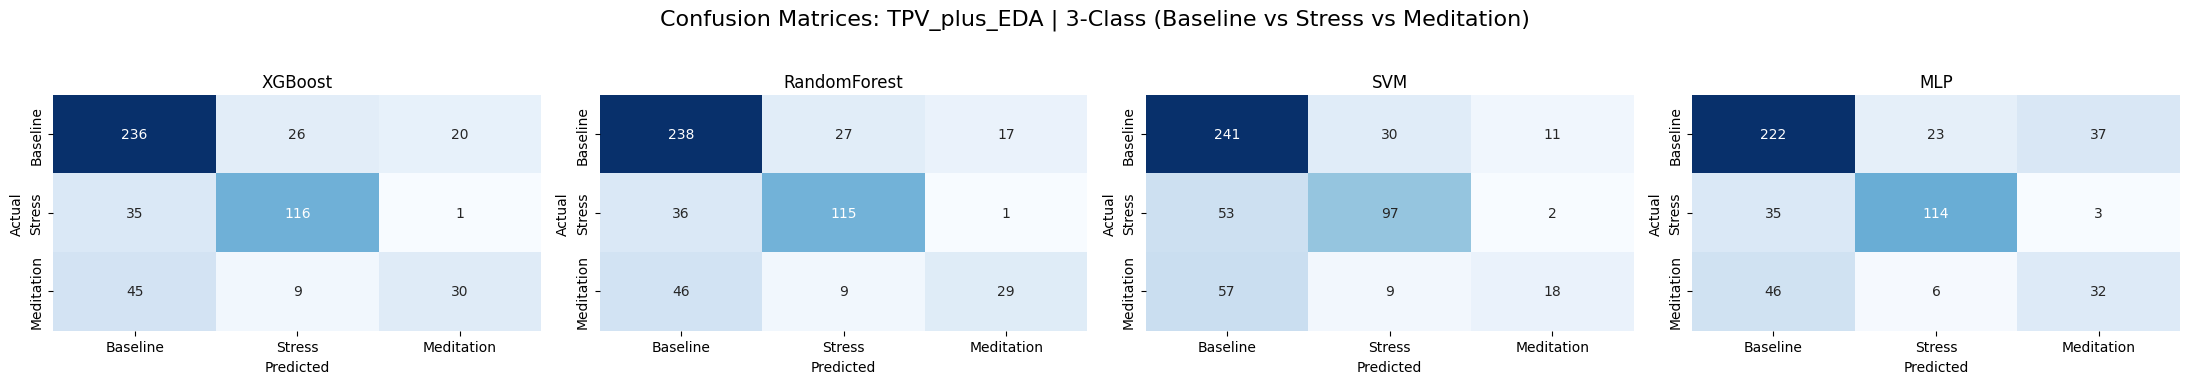


[INFO] Saved LOSO results: /mnt/data/tpv_eda_eval_results/TPV_EDA_LOSO_results.csv

[INFO] Final summary
                                                     task        model  n_features      acc  f1_macro
                   TPV_only | Binary (Baseline vs Stress)      XGBoost          11 0.774194  0.747122
                   TPV_only | Binary (Baseline vs Stress) RandomForest          11 0.767281  0.733258
                   TPV_only | Binary (Baseline vs Stress)          SVM          11 0.778802  0.745006
                   TPV_only | Binary (Baseline vs Stress)          MLP          11 0.760369  0.729789
    TPV_only | 3-Class (Baseline vs Stress vs Meditation)      XGBoost          11 0.673745  0.625884
    TPV_only | 3-Class (Baseline vs Stress vs Meditation) RandomForest          11 0.683398  0.628678
    TPV_only | 3-Class (Baseline vs Stress vs Meditation)          SVM          11 0.685328  0.606683
    TPV_only | 3-Class (Baseline vs Stress vs Meditation)          MLP        

In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =============================================================================
# CONFIG
# =============================================================================
TPV_CSV_PATH = r"/content/drive/MyDrive/Colab Notebooks/BP/TPV-csv/noQC.csv"
EDA_CSV_PATH = r"/content/drive/MyDrive/Colab Notebooks/BP/EDA_only_csv/WESAD_EDA_only_windows.csv"
OUTPUT_DIR = r"/mnt/data/tpv_eda_eval_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

LABEL_COL = "label_major"
SUBJECT_COL = "subject"

KEY_COLS = [
    "subject", "window", "window_index", "status", "status_name",
    "label_major", "t_start_sec", "t_end_sec", "major_ratio"
]

TPV_COLS = [
    "TPV22", "TPV9", "TPV4", "TPV2", "TPV0",
    "TPV28", "TPV8", "TPV19", "TPV14", "TPV26", "TPV11"
]

EDA_COLS = [
    "EDA_mean", "EDA_std", "EDA_min", "EDA_max", "EDA_median",
    "EDA_iqr", "EDA_skew", "EDA_kurtosis", "EDA_slope", "EDA_range",
    "EDA_diff_mean", "EDA_diff_std", "EDA_num_peaks",
    "EDA_peak_mean", "EDA_peak_max"
]


# =============================================================================
# Model definitions
# =============================================================================
def get_models(num_classes: int):
    objective = "binary:logistic" if num_classes == 2 else "multi:softprob"

    return {
        "XGBoost": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            objective=objective,
            random_state=42,
            use_label_encoder=False,
            eval_metric="logloss",
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),
        "SVM": SVC(
            kernel="rbf",
            C=1.0,
            probability=True,
            random_state=42
        ),
        "MLP": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            alpha=1e-4,
            solver="adam",
            random_state=42
        )
    }


# =============================================================================
# LOSO evaluation
# =============================================================================
def run_loso_evaluation(data: pd.DataFrame, feature_cols: list, task_name: str, class_names: list):
    subjects = sorted(data[SUBJECT_COL].unique())
    num_classes = len(class_names)
    models_dict = get_models(num_classes)

    print(f"\n{'='*80}")
    print(f" Task: {task_name}")
    print(f" N subjects: {len(subjects)}")
    print(f" N samples : {len(data)}")
    print(f" N features: {len(feature_cols)}")
    print(f"{'='*80}")

    fig, axes = plt.subplots(1, 4, figsize=(22, 4))
    fig.suptitle(f"Confusion Matrices: {task_name}", fontsize=16)

    results = []

    for idx, (m_name, model) in enumerate(models_dict.items()):
        all_preds = []
        all_trues = []

        for test_subj in subjects:
            train_df = data[data[SUBJECT_COL] != test_subj].copy()
            test_df = data[data[SUBJECT_COL] == test_subj].copy()

            X_train, y_train = train_df[feature_cols], train_df["target"]
            X_test, y_test = test_df[feature_cols], test_df["target"]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            all_preds.extend(preds)
            all_trues.extend(y_test)

        acc = accuracy_score(all_trues, all_preds)
        f1 = f1_score(all_trues, all_preds, average="macro")

        print(f"[{m_name:12}] Acc: {acc:.4f} | F1-Macro: {f1:.4f}")
        print(classification_report(all_trues, all_preds, target_names=class_names, digits=4))

        results.append({
            "task": task_name,
            "model": m_name,
            "n_features": len(feature_cols),
            "acc": acc,
            "f1_macro": f1
        })

        cm = confusion_matrix(all_trues, all_preds)
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=axes[idx],
            cbar=False,
            xticklabels=class_names,
            yticklabels=class_names
        )
        axes[idx].set_title(m_name)
        axes[idx].set_xlabel("Predicted")
        axes[idx].set_ylabel("Actual")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return pd.DataFrame(results)


# =============================================================================
# Main
# =============================================================================
if __name__ == "__main__":
    df_tpv = pd.read_csv(TPV_CSV_PATH)
    df_eda = pd.read_csv(EDA_CSV_PATH)

    print("[INFO] TPV CSV shape:", df_tpv.shape)
    print("[INFO] EDA CSV shape:", df_eda.shape)

    # 필요한 컬럼 존재 확인
    missing_tpv = [c for c in TPV_COLS if c not in df_tpv.columns]
    missing_eda = [c for c in EDA_COLS if c not in df_eda.columns]

    if len(missing_tpv) > 0:
        raise ValueError(f"Missing TPV columns: {missing_tpv}")
    if len(missing_eda) > 0:
        raise ValueError(f"Missing EDA columns: {missing_eda}")

    # merge
    df = pd.merge(
        df_tpv[KEY_COLS + TPV_COLS],
        df_eda[KEY_COLS + EDA_COLS],
        on=KEY_COLS,
        how="inner"
    )

    print("[INFO] Merged shape:", df.shape)

    print("\n[INFO] Label counts")
    print(df[LABEL_COL].value_counts().sort_index())

    print("\n[INFO] Subject x label counts")
    print(
        df.groupby([SUBJECT_COL, LABEL_COL])
          .size()
          .reset_index(name="n_windows")
          .to_string(index=False)
    )

    FEATURE_SETS = {
        "TPV_only": TPV_COLS,
        "EDA_only": EDA_COLS,
        "TPV_plus_EDA": TPV_COLS + EDA_COLS
    }

    all_results = []

    for feat_name, feat_cols in FEATURE_SETS.items():
        # ---------------------------------------------------------------------
        # 1) Binary classification: baseline vs stress
        # ---------------------------------------------------------------------
        df_bin = df[df[LABEL_COL].isin([1, 2])].copy()
        le_bin = LabelEncoder()
        df_bin["target"] = le_bin.fit_transform(df_bin[LABEL_COL])

        result_bin = run_loso_evaluation(
            df_bin,
            feat_cols,
            f"{feat_name} | Binary (Baseline vs Stress)",
            ["Baseline", "Stress"]
        )

        # ---------------------------------------------------------------------
        # 2) 3-class classification: baseline vs stress vs meditation
        # ---------------------------------------------------------------------
        df_tri = df[df[LABEL_COL].isin([1, 2, 4])].copy()
        le_tri = LabelEncoder()
        df_tri["target"] = le_tri.fit_transform(df_tri[LABEL_COL])

        result_tri = run_loso_evaluation(
            df_tri,
            feat_cols,
            f"{feat_name} | 3-Class (Baseline vs Stress vs Meditation)",
            ["Baseline", "Stress", "Meditation"]
        )

        all_results.append(result_bin)
        all_results.append(result_tri)

    df_results = pd.concat(all_results, axis=0, ignore_index=True)

    results_csv = os.path.join(OUTPUT_DIR, "TPV_EDA_LOSO_results.csv")
    df_results.to_csv(results_csv, index=False)

    print(f"\n[INFO] Saved LOSO results: {results_csv}")
    print("\n[INFO] Final summary")
    print(df_results.to_string(index=False))

# 4-2) BVP-TPV + EDA with QC

[INFO] TPV CSV shape: (429, 52)
[INFO] EDA CSV shape: (518, 24)
[INFO] Merged shape: (429, 35)

[INFO] Label counts
label_major
1    255
2     92
4     82
Name: count, dtype: int64

[INFO] Subject x label counts
subject  label_major  n_windows
    S10            1         17
    S10            2          9
    S10            4          5
    S11            1         18
    S11            2          4
    S11            4          5
    S13            1         15
    S13            2          5
    S13            4          6
    S14            1         19
    S14            2          5
    S14            4          6
    S15            1         18
    S15            2          6
    S15            4          5
    S16            1         14
    S16            2          8
    S16            4          6
    S17            1         19
    S17            2          7
    S17            4          5
     S2            1         15
     S2            2          8
     S2            4

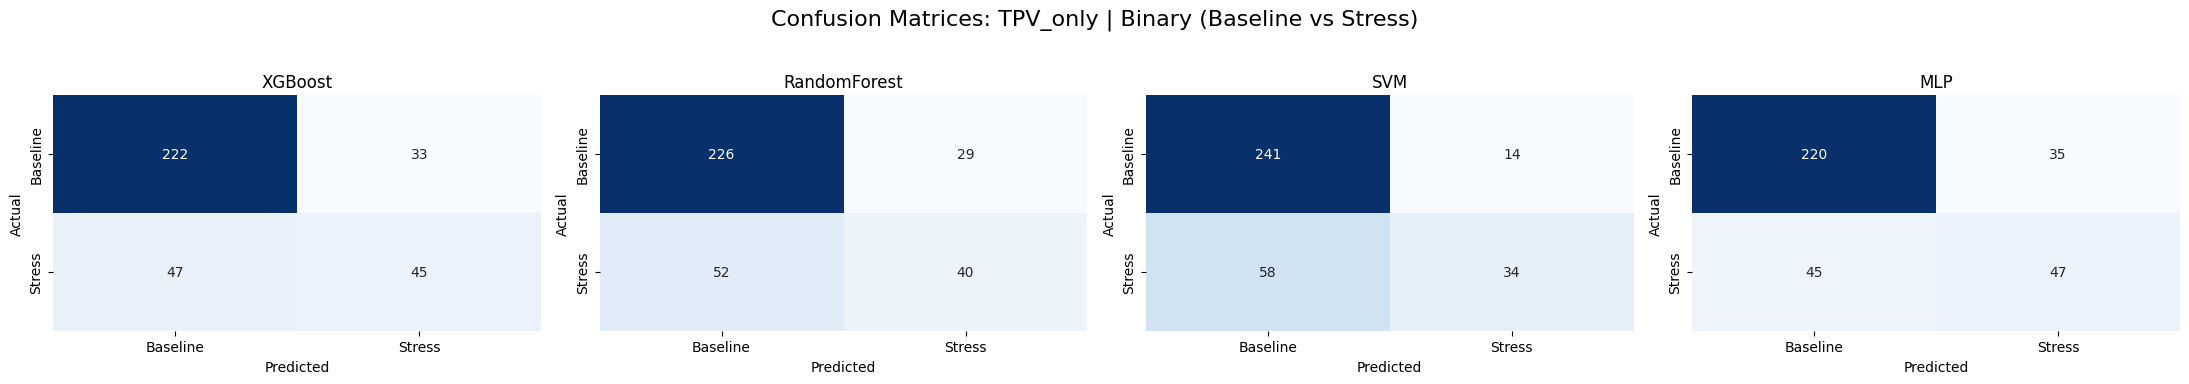


 Task: TPV_only | 3-Class (Baseline vs Stress vs Meditation)
 N subjects: 15
 N samples : 429
 N features: 11
[XGBoost     ] Acc: 0.6643 | F1-Macro: 0.5857
              precision    recall  f1-score   support

    Baseline     0.7148    0.8157    0.7619       255
      Stress     0.4937    0.4239    0.4561        92
  Meditation     0.6441    0.4634    0.5390        82

    accuracy                         0.6643       429
   macro avg     0.6175    0.5677    0.5857       429
weighted avg     0.6538    0.6643    0.6537       429

[RandomForest] Acc: 0.6597 | F1-Macro: 0.5706
              precision    recall  f1-score   support

    Baseline     0.7020    0.8314    0.7612       255
      Stress     0.4933    0.4022    0.4431        92
  Meditation     0.6538    0.4146    0.5075        82

    accuracy                         0.6597       429
   macro avg     0.6164    0.5494    0.5706       429
weighted avg     0.6480    0.6597    0.6445       429

[SVM         ] Acc: 0.6853 | F1-Mac

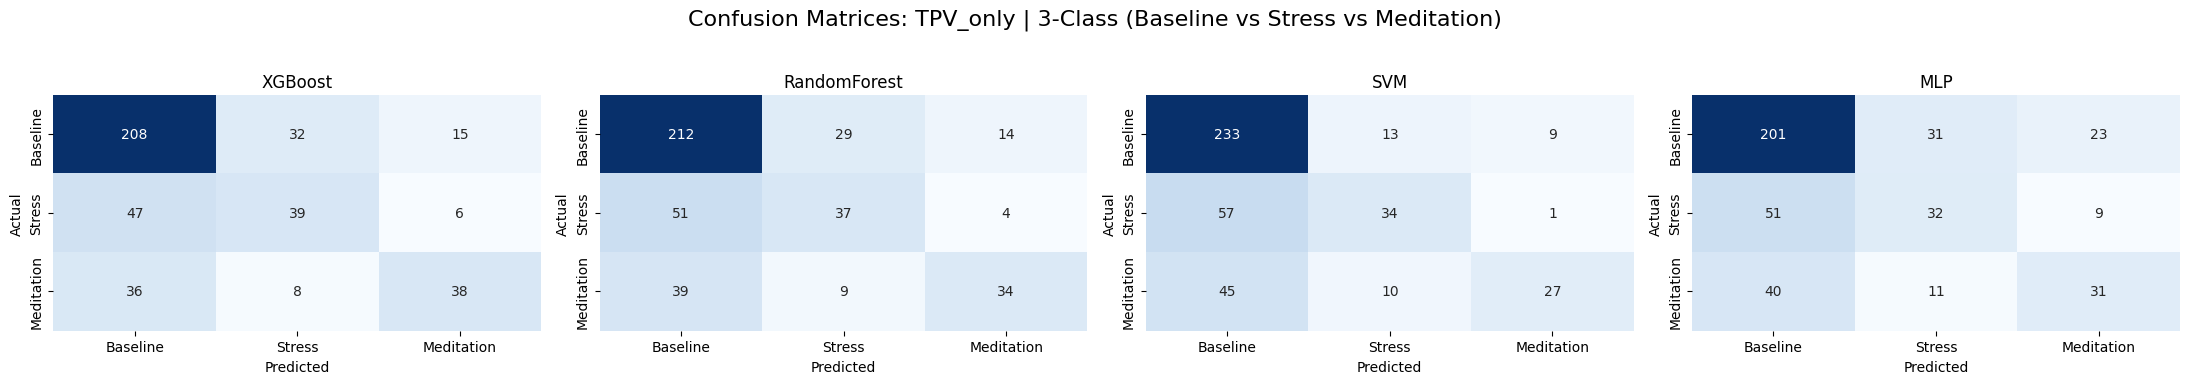


 Task: EDA_only | Binary (Baseline vs Stress)
 N subjects: 15
 N samples : 347
 N features: 15
[XGBoost     ] Acc: 0.8790 | F1-Macro: 0.8413
              precision    recall  f1-score   support

    Baseline     0.9080    0.9294    0.9186       255
      Stress     0.7907    0.7391    0.7640        92

    accuracy                         0.8790       347
   macro avg     0.8494    0.8343    0.8413       347
weighted avg     0.8769    0.8790    0.8776       347

[RandomForest] Acc: 0.8213 | F1-Macro: 0.7691
              precision    recall  f1-score   support

    Baseline     0.8755    0.8824    0.8789       255
      Stress     0.6667    0.6522    0.6593        92

    accuracy                         0.8213       347
   macro avg     0.7711    0.7673    0.7691       347
weighted avg     0.8201    0.8213    0.8207       347

[SVM         ] Acc: 0.7954 | F1-Macro: 0.7078
              precision    recall  f1-score   support

    Baseline     0.8262    0.9137    0.8678       255
   

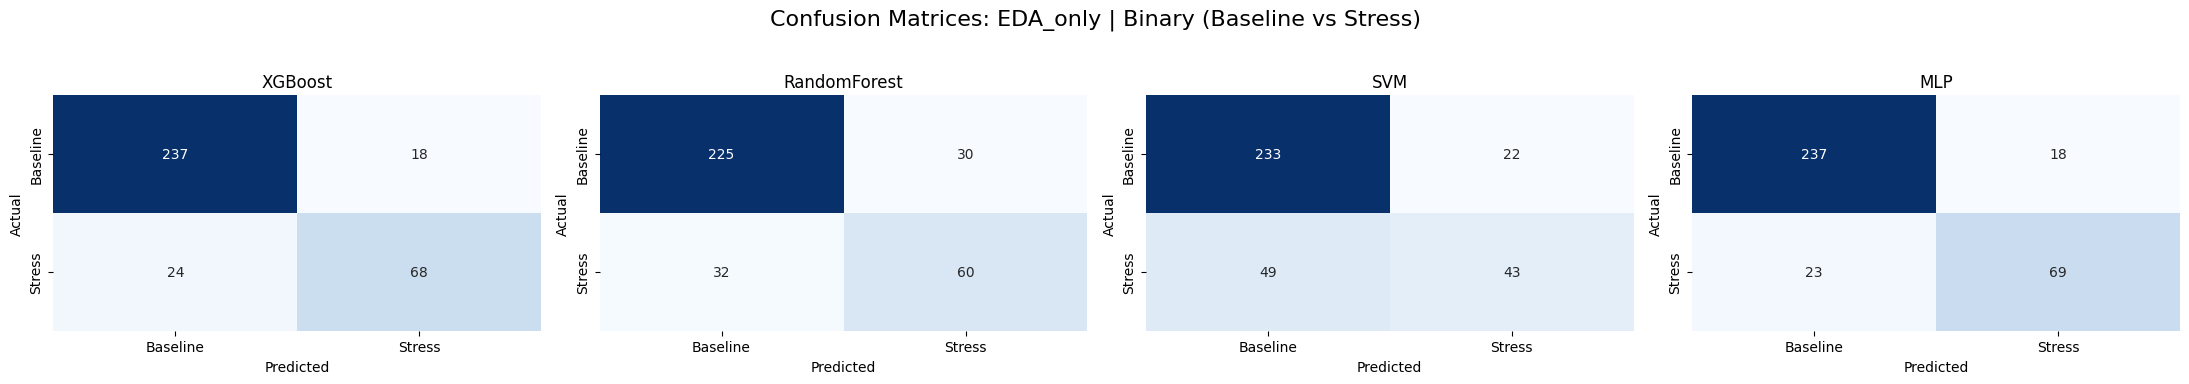


 Task: EDA_only | 3-Class (Baseline vs Stress vs Meditation)
 N subjects: 15
 N samples : 429
 N features: 15
[XGBoost     ] Acc: 0.6457 | F1-Macro: 0.5786
              precision    recall  f1-score   support

    Baseline     0.6920    0.7490    0.7194       255
      Stress     0.7529    0.6957    0.7232        92
  Meditation     0.3235    0.2683    0.2933        82

    accuracy                         0.6457       429
   macro avg     0.5895    0.5710    0.5786       429
weighted avg     0.6347    0.6457    0.6388       429

[RandomForest] Acc: 0.6224 | F1-Macro: 0.5628
              precision    recall  f1-score   support

    Baseline     0.6779    0.7098    0.6935       255
      Stress     0.6778    0.6630    0.6703        92
  Meditation     0.3472    0.3049    0.3247        82

    accuracy                         0.6224       429
   macro avg     0.5676    0.5592    0.5628       429
weighted avg     0.6147    0.6224    0.6180       429

[SVM         ] Acc: 0.6480 | F1-Mac

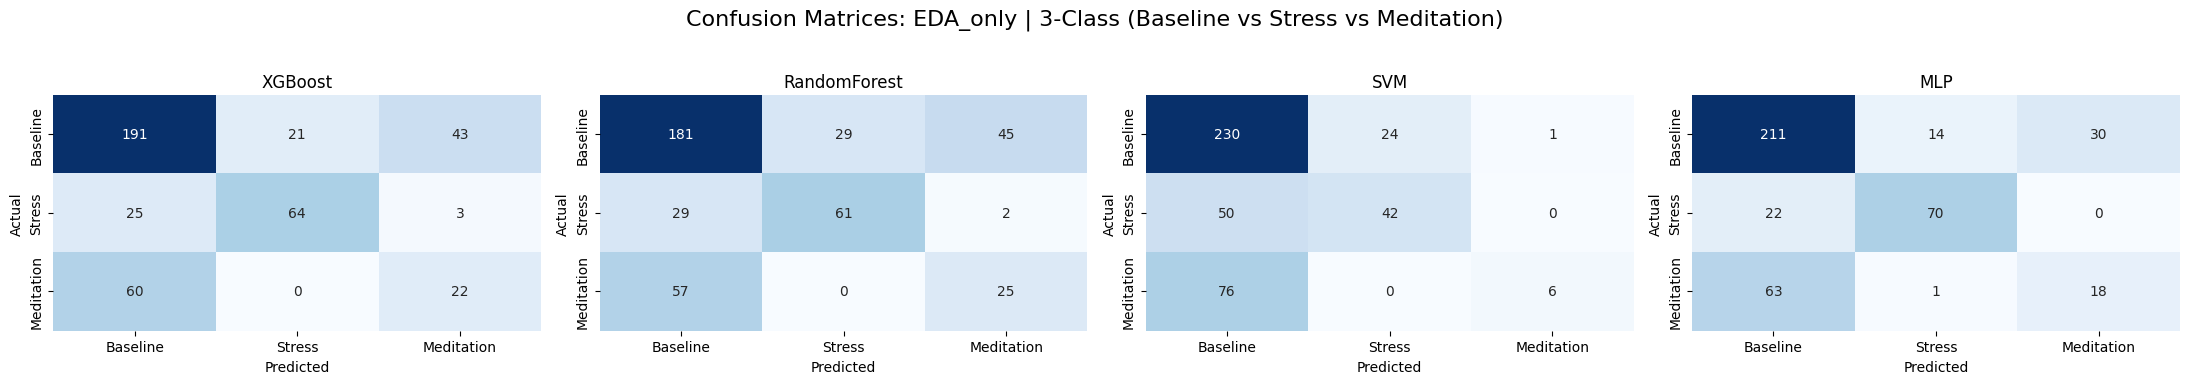


 Task: TPV_plus_EDA | Binary (Baseline vs Stress)
 N subjects: 15
 N samples : 347
 N features: 26
[XGBoost     ] Acc: 0.8559 | F1-Macro: 0.8151
              precision    recall  f1-score   support

    Baseline     0.9020    0.9020    0.9020       255
      Stress     0.7283    0.7283    0.7283        92

    accuracy                         0.8559       347
   macro avg     0.8151    0.8151    0.8151       347
weighted avg     0.8559    0.8559    0.8559       347

[RandomForest] Acc: 0.8703 | F1-Macro: 0.8318
              precision    recall  f1-score   support

    Baseline     0.9070    0.9176    0.9123       255
      Stress     0.7640    0.7391    0.7514        92

    accuracy                         0.8703       347
   macro avg     0.8355    0.8284    0.8318       347
weighted avg     0.8691    0.8703    0.8696       347

[SVM         ] Acc: 0.8242 | F1-Macro: 0.7466
              precision    recall  f1-score   support

    Baseline     0.8415    0.9373    0.8868       255

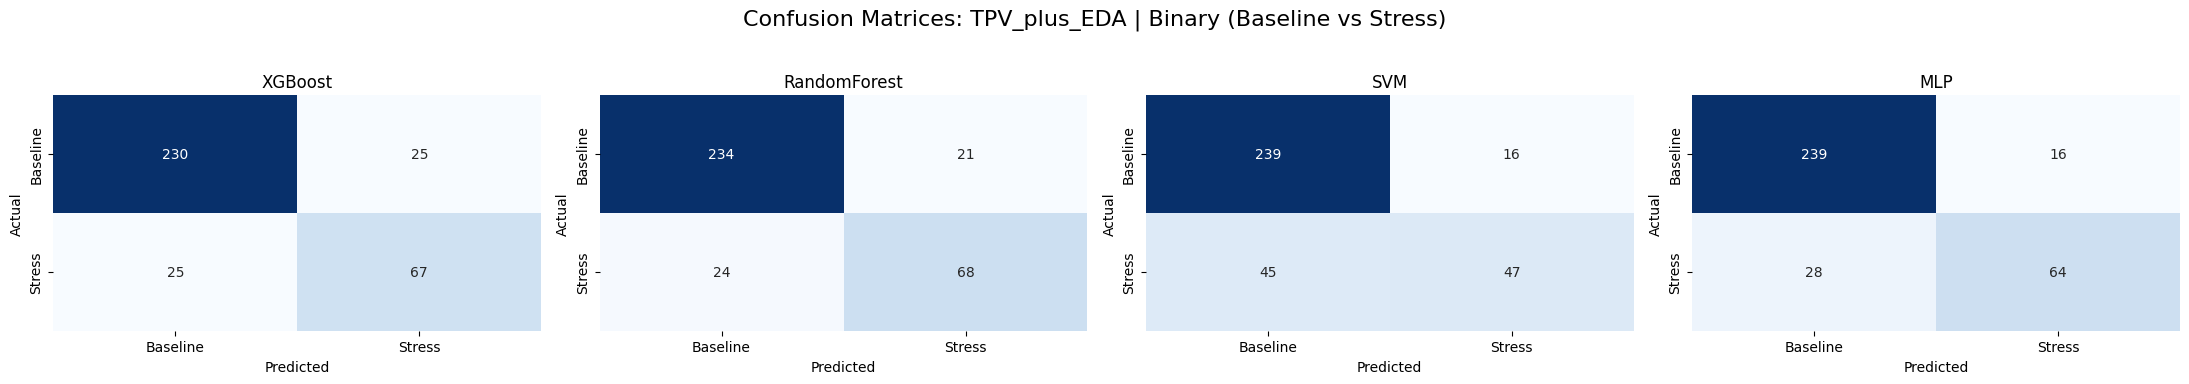


 Task: TPV_plus_EDA | 3-Class (Baseline vs Stress vs Meditation)
 N subjects: 15
 N samples : 429
 N features: 26
[XGBoost     ] Acc: 0.7483 | F1-Macro: 0.6878
              precision    recall  f1-score   support

    Baseline     0.7666    0.8627    0.8118       255
      Stress     0.7303    0.7065    0.7182        92
  Meditation     0.6792    0.4390    0.5333        82

    accuracy                         0.7483       429
   macro avg     0.7254    0.6694    0.6878       429
weighted avg     0.7421    0.7483    0.7385       429

[RandomForest] Acc: 0.7389 | F1-Macro: 0.6715
              precision    recall  f1-score   support

    Baseline     0.7416    0.8667    0.7993       255
      Stress     0.7857    0.7174    0.7500        92
  Meditation     0.6383    0.3659    0.4651        82

    accuracy                         0.7389       429
   macro avg     0.7219    0.6500    0.6715       429
weighted avg     0.7313    0.7389    0.7248       429

[SVM         ] Acc: 0.6993 | F1

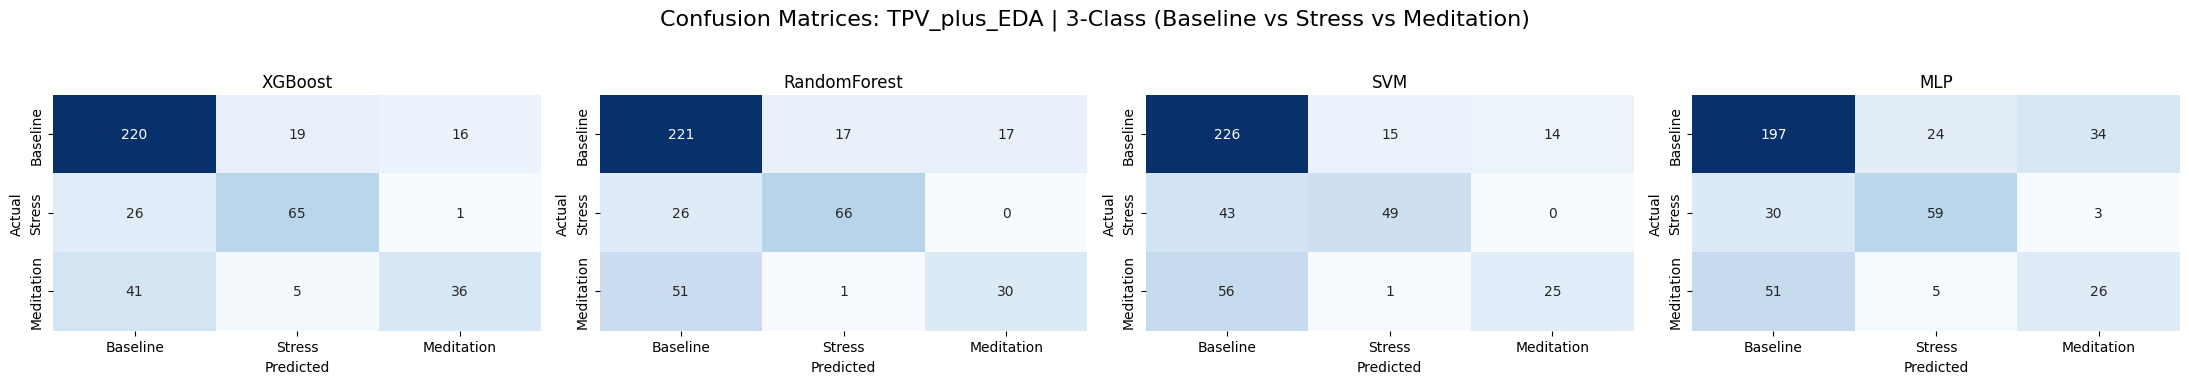


[INFO] Saved LOSO results: /mnt/data/tpv_eda_eval_results/TPV_EDA_LOSO_results.csv

[INFO] Final summary
                                                     task        model  n_features      acc  f1_macro
                   TPV_only | Binary (Baseline vs Stress)      XGBoost          11 0.769452  0.688370
                   TPV_only | Binary (Baseline vs Stress) RandomForest          11 0.766571  0.672462
                   TPV_only | Binary (Baseline vs Stress)          SVM          11 0.792507  0.677875
                   TPV_only | Binary (Baseline vs Stress)          MLP          11 0.769452  0.693192
    TPV_only | 3-Class (Baseline vs Stress vs Meditation)      XGBoost          11 0.664336  0.585684
    TPV_only | 3-Class (Baseline vs Stress vs Meditation) RandomForest          11 0.659674  0.570599
    TPV_only | 3-Class (Baseline vs Stress vs Meditation)          SVM          11 0.685315  0.566663
    TPV_only | 3-Class (Baseline vs Stress vs Meditation)          MLP        

In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =============================================================================
# CONFIG
# =============================================================================
TPV_CSV_PATH = r"/content/drive/MyDrive/Colab Notebooks/BP/TPV-csv/after_motion-artifact_removed.csv"
EDA_CSV_PATH = r"/content/drive/MyDrive/Colab Notebooks/BP/EDA_only_csv/WESAD_EDA_only_windows.csv"
OUTPUT_DIR = r"/mnt/data/tpv_eda_eval_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

LABEL_COL = "label_major"
SUBJECT_COL = "subject"

KEY_COLS = [
    "subject", "window", "window_index", "status", "status_name",
    "label_major", "t_start_sec", "t_end_sec", "major_ratio"
]

TPV_COLS = [
    "TPV22", "TPV9", "TPV4", "TPV2", "TPV0",
    "TPV28", "TPV8", "TPV19", "TPV14", "TPV26", "TPV11"
]

EDA_COLS = [
    "EDA_mean", "EDA_std", "EDA_min", "EDA_max", "EDA_median",
    "EDA_iqr", "EDA_skew", "EDA_kurtosis", "EDA_slope", "EDA_range",
    "EDA_diff_mean", "EDA_diff_std", "EDA_num_peaks",
    "EDA_peak_mean", "EDA_peak_max"
]


# =============================================================================
# Model definitions
# =============================================================================
def get_models(num_classes: int):
    objective = "binary:logistic" if num_classes == 2 else "multi:softprob"

    return {
        "XGBoost": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            objective=objective,
            random_state=42,
            use_label_encoder=False,
            eval_metric="logloss",
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),
        "SVM": SVC(
            kernel="rbf",
            C=1.0,
            probability=True,
            random_state=42
        ),
        "MLP": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            alpha=1e-4,
            solver="adam",
            random_state=42
        )
    }


# =============================================================================
# LOSO evaluation
# =============================================================================
def run_loso_evaluation(data: pd.DataFrame, feature_cols: list, task_name: str, class_names: list):
    subjects = sorted(data[SUBJECT_COL].unique())
    num_classes = len(class_names)
    models_dict = get_models(num_classes)

    print(f"\n{'='*80}")
    print(f" Task: {task_name}")
    print(f" N subjects: {len(subjects)}")
    print(f" N samples : {len(data)}")
    print(f" N features: {len(feature_cols)}")
    print(f"{'='*80}")

    fig, axes = plt.subplots(1, 4, figsize=(22, 4))
    fig.suptitle(f"Confusion Matrices: {task_name}", fontsize=16)

    results = []

    for idx, (m_name, model) in enumerate(models_dict.items()):
        all_preds = []
        all_trues = []

        for test_subj in subjects:
            train_df = data[data[SUBJECT_COL] != test_subj].copy()
            test_df = data[data[SUBJECT_COL] == test_subj].copy()

            X_train, y_train = train_df[feature_cols], train_df["target"]
            X_test, y_test = test_df[feature_cols], test_df["target"]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            all_preds.extend(preds)
            all_trues.extend(y_test)

        acc = accuracy_score(all_trues, all_preds)
        f1 = f1_score(all_trues, all_preds, average="macro")

        print(f"[{m_name:12}] Acc: {acc:.4f} | F1-Macro: {f1:.4f}")
        print(classification_report(all_trues, all_preds, target_names=class_names, digits=4))

        results.append({
            "task": task_name,
            "model": m_name,
            "n_features": len(feature_cols),
            "acc": acc,
            "f1_macro": f1
        })

        cm = confusion_matrix(all_trues, all_preds)
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=axes[idx],
            cbar=False,
            xticklabels=class_names,
            yticklabels=class_names
        )
        axes[idx].set_title(m_name)
        axes[idx].set_xlabel("Predicted")
        axes[idx].set_ylabel("Actual")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return pd.DataFrame(results)


# =============================================================================
# Main
# =============================================================================
if __name__ == "__main__":
    df_tpv = pd.read_csv(TPV_CSV_PATH)
    df_eda = pd.read_csv(EDA_CSV_PATH)

    print("[INFO] TPV CSV shape:", df_tpv.shape)
    print("[INFO] EDA CSV shape:", df_eda.shape)

    # 필요한 컬럼 존재 확인
    missing_tpv = [c for c in TPV_COLS if c not in df_tpv.columns]
    missing_eda = [c for c in EDA_COLS if c not in df_eda.columns]

    if len(missing_tpv) > 0:
        raise ValueError(f"Missing TPV columns: {missing_tpv}")
    if len(missing_eda) > 0:
        raise ValueError(f"Missing EDA columns: {missing_eda}")

    # merge
    df = pd.merge(
        df_tpv[KEY_COLS + TPV_COLS],
        df_eda[KEY_COLS + EDA_COLS],
        on=KEY_COLS,
        how="inner"
    )

    print("[INFO] Merged shape:", df.shape)

    print("\n[INFO] Label counts")
    print(df[LABEL_COL].value_counts().sort_index())

    print("\n[INFO] Subject x label counts")
    print(
        df.groupby([SUBJECT_COL, LABEL_COL])
          .size()
          .reset_index(name="n_windows")
          .to_string(index=False)
    )

    FEATURE_SETS = {
        "TPV_only": TPV_COLS,
        "EDA_only": EDA_COLS,
        "TPV_plus_EDA": TPV_COLS + EDA_COLS
    }

    all_results = []

    for feat_name, feat_cols in FEATURE_SETS.items():
        # ---------------------------------------------------------------------
        # 1) Binary classification: baseline vs stress
        # ---------------------------------------------------------------------
        df_bin = df[df[LABEL_COL].isin([1, 2])].copy()
        le_bin = LabelEncoder()
        df_bin["target"] = le_bin.fit_transform(df_bin[LABEL_COL])

        result_bin = run_loso_evaluation(
            df_bin,
            feat_cols,
            f"{feat_name} | Binary (Baseline vs Stress)",
            ["Baseline", "Stress"]
        )

        # ---------------------------------------------------------------------
        # 2) 3-class classification: baseline vs stress vs meditation
        # ---------------------------------------------------------------------
        df_tri = df[df[LABEL_COL].isin([1, 2, 4])].copy()
        le_tri = LabelEncoder()
        df_tri["target"] = le_tri.fit_transform(df_tri[LABEL_COL])

        result_tri = run_loso_evaluation(
            df_tri,
            feat_cols,
            f"{feat_name} | 3-Class (Baseline vs Stress vs Meditation)",
            ["Baseline", "Stress", "Meditation"]
        )

        all_results.append(result_bin)
        all_results.append(result_tri)

    df_results = pd.concat(all_results, axis=0, ignore_index=True)

    results_csv = os.path.join(OUTPUT_DIR, "TPV_EDA_LOSO_results.csv")
    df_results.to_csv(results_csv, index=False)

    print(f"\n[INFO] Saved LOSO results: {results_csv}")
    print("\n[INFO] Final summary")
    print(df_results.to_string(index=False))